In [199]:
import numpy as np
from matplotlib import pyplot as plt
import nibabel as nb
from scipy.ndimage import gaussian_filter
from scipy.ndimage import distance_transform_edt
from glob import glob
import tifffile as tiff
import sys
import os
sys.path.append('../')

# from slice_structure_identification_functions import compute_signed_distance_weight as compute_signed_distance_weight
# from slice_structure_identification_functions import compute_signed_distance_weight_filled as compute_signed_distance_weight_filled
from slice_registration_functions import apply_coordinate_mapping_2d, downsample_image

In [4]:
root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'
# root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_50/'
slice_name = 'zefir_0049__Image_36_-_20x_cellCount_29'
source_img = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix.nii.gz")

mapping_img = os.path.join(root_dir,f"init_translation_slice_0049/{slice_name}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
comparison_img = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg0nl_ants-def0.nii.gz")

# mapping_img2 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_rigsyn_0_ants-map.nii.gz")
# comparison_img2 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_rigsyn_0_ants-def0.nii.gz")

mapping_img2 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_rigsyn_4_ants-map.nii.gz")
comparison_img2 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_rigsyn_4_ants-def0.nii.gz")

mapping_img3 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
comparison_img3 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-def0.nii.gz")



576.5641807282227


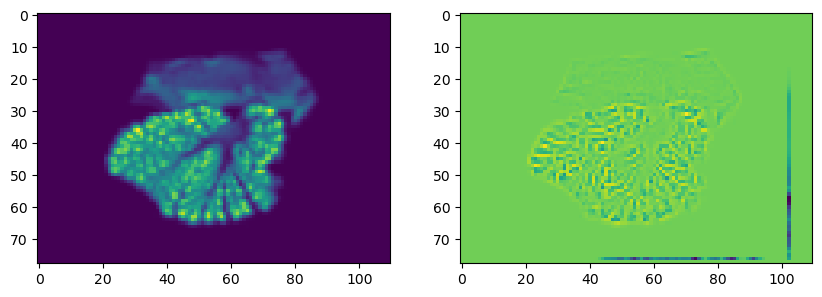

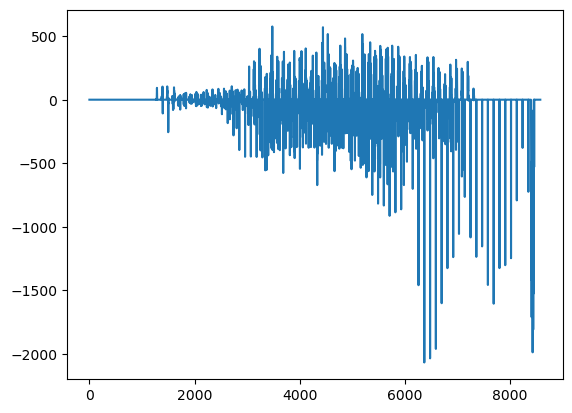

In [5]:
c_map = compose_mapping_chain_2d([mapping_img, mapping_img3])
res2 = apply_coordinate_mapping_2d(nb.load(source_img), c_map)

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(nb.load(comparison_img3).get_fdata())
plt.subplot(1,2,2)
diff = nb.load(comparison_img3).get_fdata()-res2.get_fdata()
plt.imshow(diff)
plt.figure()
plt.plot((nb.load(comparison_img3).get_fdata()-res2.get_fdata()).flatten())
print(np.max(diff))



In [11]:


#import nighres as nr
#import nibabel as nib

root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'
# root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_50/'
slice_name = 'zefir_0049__Image_36_-_20x_cellCount_29'
source_img = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix.nii.gz")

# source_data = nib.load(source_img).get_fdata()

mapping_img = os.path.join(root_dir,f"init_translation_slice_0049/{slice_name}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
comparison_img = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg0nl_ants-def0.nii.gz")

mapping_img2 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_rigsyn_0_ants-map.nii.gz")
comparison_img2 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_rigsyn_0_ants-def0.nii.gz")



mapping_img3 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
comparison_img3 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-def0.nii.gz")

mapping_img4 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz")
comparison_img4 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")
# mapping_data = nib.load(mapping_img).get_fdata()

# inverse_mapping_img = os.path.join(root_dir,"init_translation_slice_0020/zefir_0020__Image_11_-_20x_01_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-invmap.nii.gz")


# deform = os.path.join(root_dir,"zefir_0020__Image_11_-_20x_01_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-def0.nii.gz")
# deform_data = nib.load(deform).get_fdata()


# nr.registration.apply_coordinate_mappings(source_data, mapping_data, output_dir="/data/neuralabc/johmat/phase_ml/tmp/reg_test_output")



In [14]:
# Step-by-step verification
# Step 1: original → coreg0nl
res0 = apply_coordinate_mapping_2d(nb.load(source_img), nb.load(mapping_img))
diff1 = nb.load(comparison_img).get_fdata() - res0.get_fdata()
print(f"Step 1 (coreg0nl) max diff: {np.abs(diff1).max():.6f}")

# Step 2: coreg0nl_def0 → win12 (using actual coreg0nl_def0 as input)
res1_from_def0 = apply_coordinate_mapping_2d(nb.load(comparison_img), nb.load(mapping_img3))
diff2 = nb.load(comparison_img3).get_fdata() - res1_from_def0.get_fdata()
print(f"Step 2 (win12 from coreg0nl_def0) max diff: {np.abs(diff2).max():.6f}")

# Step 3: win12_def0 → groupwise (using actual win12_def0 as input)
res2_from_def0 = apply_coordinate_mapping_2d(nb.load(comparison_img3), nb.load(mapping_img4))
diff3 = nb.load(comparison_img4).get_fdata() - res2_from_def0.get_fdata()
print(f"Step 3 (groupwise from win12_def0) max diff: {np.abs(diff3).max():.6f}")

Step 1 (coreg0nl) max diff: 0.000000
Step 2 (win12 from coreg0nl_def0) max diff: 0.003053
Step 3 (groupwise from win12_def0) max diff: 0.002547


In [15]:
c_map = compose_mapping_chain_2d([mapping_img, mapping_img3, mapping_img4])
res3_from_def0 = apply_coordinate_mapping_2d(nb.load(source_img), c_map)
diff4 = nb.load(comparison_img4).get_fdata() - res3_from_def0.get_fdata()
print(f"Step 4 (rigsyn -> win12 -> groupwise_iter3) max diff: {np.abs(diff4).max():.6f}")

Step 4 (rigsyn -> win12 -> groupwise_iter3) max diff: 1794.186424


In [16]:
# Diagnostic: check shapes and value ranges of all maps
for label, path in [("coreg0nl_map", mapping_img), 
                     ("win12_map", mapping_img3), 
                     ("groupwise_map", mapping_img4)]:
    m = nb.load(path).get_fdata()
    print(f"{label}: shape={m.shape}, "
          f"X range=[{m[:,:,0].min():.1f}, {m[:,:,0].max():.1f}], "
          f"Y range=[{m[:,:,1].min():.1f}, {m[:,:,1].max():.1f}]")

# Also check source and def0 images
for label, path in [("source_img", source_img), 
                     ("coreg0nl_def0", comparison_img),
                     ("win12_def0", comparison_img3), 
                     ("groupwise_def0", comparison_img4)]:
    d = nb.load(path).get_fdata()
    print(f"{label}: shape={d.shape}, range=[{d.min():.1f}, {d.max():.1f}]")

# Check intermediate composition
c_map_step1 = compose_coordinate_mappings_2d(nb.load(mapping_img), nb.load(mapping_img3))
print(f"\ncomposed(coreg0nl, win12): shape={c_map_step1.get_fdata().shape}, "
      f"X range=[{c_map_step1.get_fdata()[:,:,0].min():.1f}, {c_map_step1.get_fdata()[:,:,0].max():.1f}], "
      f"Y range=[{c_map_step1.get_fdata()[:,:,1].min():.1f}, {c_map_step1.get_fdata()[:,:,1].max():.1f}]")

# Test 2-step composition only
res_2step = apply_coordinate_mapping_2d(nb.load(source_img), c_map_step1)
diff_2step = nb.load(comparison_img3).get_fdata() - res_2step.get_fdata()
print(f"\n2-step compose (coreg0nl+win12) max diff: {np.abs(diff_2step).max():.6f}")

coreg0nl_map: shape=(78, 110, 2), X range=[0.0, 75.5], Y range=[0.0, 93.5]
win12_map: shape=(78, 110, 2), X range=[0.2, 77.0], Y range=[0.0, 108.6]
groupwise_map: shape=(78, 110, 2), X range=[0.0, 77.0], Y range=[0.0, 109.0]
source_img: shape=(77, 95), range=[0.0, 2373.0]
coreg0nl_def0: shape=(78, 110), range=[0.0, 2114.2]
win12_def0: shape=(78, 110), range=[0.0, 1906.8]
groupwise_def0: shape=(78, 110), range=[0.0, 1822.7]

composed(coreg0nl, win12): shape=(78, 110, 2), X range=[0.0, 74.8], Y range=[0.0, 93.1]

2-step compose (coreg0nl+win12) max diff: 2069.213290


Sequential 3-step max diff: 0.003598
Composed 3-step max diff: 1794.186424

Worst pixel at (70, 102):
  Expected (groupwise_def0): 0.0000
  Composed result:           1794.1864
  Sequential result:         0.0000
  Composed coord: (31.8944, 42.7663)
  M3 coord at worst: (69.9981, 101.9896)

  win12_def0 at M3 coord: 0.0000
  source at composed coord: 1794.1864

  composed_12 at M3 coord: (31.8944, 42.7663)
  M1 at M3 coord (WRONG - should go through M2): (0.7259, 0.9766)
  M2 at M3 coord: (70.2230, 101.5378)
  M1 at M2(M3) coord (correct chain): (32.2256, 43.2152)


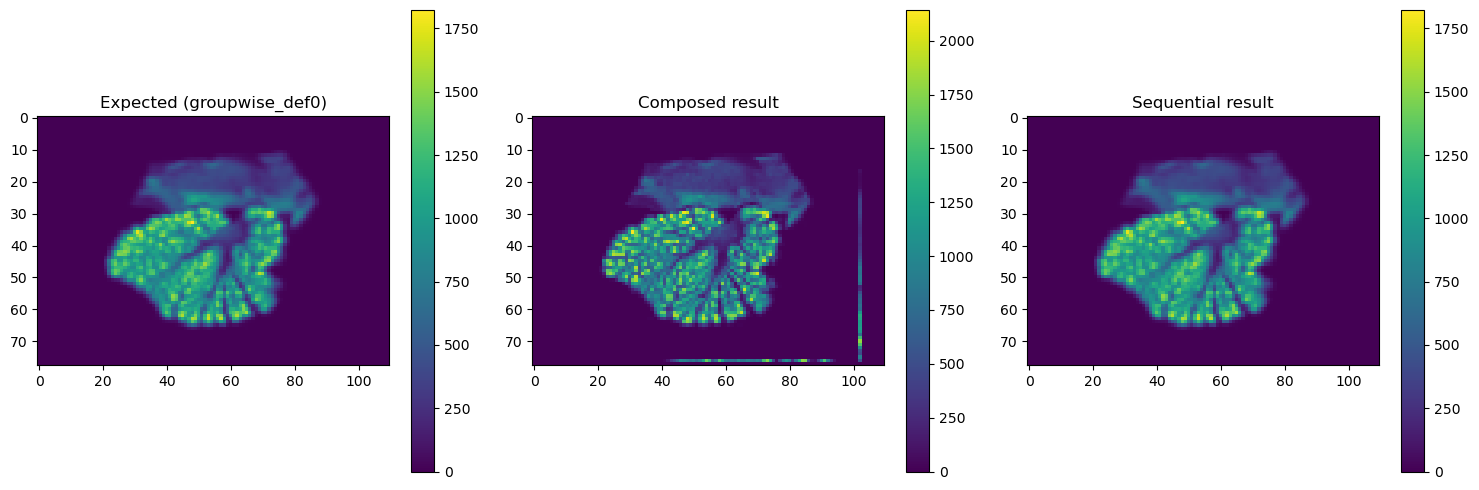

In [17]:
from scipy.ndimage import map_coordinates as mc

# Load all raw data (no NIfTI wrapping)
src = nb.load(source_img).get_fdata()
expected = nb.load(comparison_img4).get_fdata()
m1d = nb.load(mapping_img).get_fdata()    # coreg0nl map
m2d = nb.load(mapping_img3).get_fdata()   # win12 map
m3d = nb.load(mapping_img4).get_fdata()   # groupwise map

# === Test 1: Sequential application (3 interpolation steps) ===
s1 = mc(src, [m1d[:,:,0], m1d[:,:,1]], order=1, mode='constant', cval=0)
s2 = mc(s1, [m2d[:,:,0], m2d[:,:,1]], order=1, mode='constant', cval=0)
s3 = mc(s2, [m3d[:,:,0], m3d[:,:,1]], order=1, mode='constant', cval=0)
print(f"Sequential 3-step max diff: {np.abs(expected - s3).max():.6f}")

# === Test 2: Composed coordinates applied directly ===
cx12 = mc(m1d[:,:,0], [m2d[:,:,0], m2d[:,:,1]], order=1, mode='nearest')
cy12 = mc(m1d[:,:,1], [m2d[:,:,0], m2d[:,:,1]], order=1, mode='nearest')
cx123 = mc(cx12, [m3d[:,:,0], m3d[:,:,1]], order=1, mode='nearest')
cy123 = mc(cy12, [m3d[:,:,0], m3d[:,:,1]], order=1, mode='nearest')
result_composed = mc(src, [cx123, cy123], order=1, mode='constant', cval=0)
print(f"Composed 3-step max diff: {np.abs(expected - result_composed).max():.6f}")

# === Test 3: Find the worst pixel and diagnose ===
diffs = np.abs(expected - result_composed)
worst = np.unravel_index(np.argmax(diffs), diffs.shape)
print(f"\nWorst pixel at {worst}:")
print(f"  Expected (groupwise_def0): {expected[worst]:.4f}")
print(f"  Composed result:           {result_composed[worst]:.4f}")
print(f"  Sequential result:         {s3[worst]:.4f}")
print(f"  Composed coord: ({cx123[worst]:.4f}, {cy123[worst]:.4f})")
print(f"  M3 coord at worst: ({m3d[worst[0], worst[1], 0]:.4f}, {m3d[worst[0], worst[1], 1]:.4f})")

# === Test 4: Check what the sequential intermediate looks like at that pixel ===
# What does win12_def0 look like at the M3 coordinate?
win12_def0 = nb.load(comparison_img3).get_fdata()
m3_x, m3_y = m3d[worst[0], worst[1], 0], m3d[worst[0], worst[1], 1]
win12_val = mc(win12_def0, [[m3_x], [m3_y]], order=1, mode='constant', cval=0)[0]
print(f"\n  win12_def0 at M3 coord: {win12_val:.4f}")
print(f"  source at composed coord: {mc(src, [[cx123[worst]],[cy123[worst]]], order=1, mode='constant', cval=0)[0]:.4f}")

# === Test 5: Check if composed_12 at M3 coord matches what we expect ===
c12_x = mc(cx12, [[m3_x], [m3_y]], order=1, mode='nearest')[0]
c12_y = mc(cy12, [[m3_x], [m3_y]], order=1, mode='nearest')[0]
print(f"\n  composed_12 at M3 coord: ({c12_x:.4f}, {c12_y:.4f})")
# Where does M1 map M3's coordinate?
m1_x_at_m3 = mc(m1d[:,:,0], [[m3_x], [m3_y]], order=1, mode='nearest')[0]
m1_y_at_m3 = mc(m1d[:,:,1], [[m3_x], [m3_y]], order=1, mode='nearest')[0]
print(f"  M1 at M3 coord (WRONG - should go through M2): ({m1_x_at_m3:.4f}, {m1_y_at_m3:.4f})")
# Where does M2 map M3's coordinate?
m2_x_at_m3 = mc(m2d[:,:,0], [[m3_x], [m3_y]], order=1, mode='nearest')[0]
m2_y_at_m3 = mc(m2d[:,:,1], [[m3_x], [m3_y]], order=1, mode='nearest')[0]
print(f"  M2 at M3 coord: ({m2_x_at_m3:.4f}, {m2_y_at_m3:.4f})")
# Then M1 at that M2 result:
m1_x_chain = mc(m1d[:,:,0], [[m2_x_at_m3], [m2_y_at_m3]], order=1, mode='nearest')[0]
m1_y_chain = mc(m1d[:,:,1], [[m2_x_at_m3], [m2_y_at_m3]], order=1, mode='nearest')[0]
print(f"  M1 at M2(M3) coord (correct chain): ({m1_x_chain:.4f}, {m1_y_chain:.4f})")

# === Test 6: Visualize ===
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(expected)
plt.title('Expected (groupwise_def0)')
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(result_composed)
plt.title('Composed result')
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(s3)
plt.title('Sequential result')
plt.colorbar()
plt.tight_layout()

In [129]:
# KEY DIAGNOSTIC: Is M1 (coreg0nl_map) close to identity?
m1d = nb.load(mapping_img).get_fdata()
identity_x = np.arange(m1d.shape[0])[:,None] * np.ones(m1d.shape[1])[None,:]
identity_y = np.ones(m1d.shape[0])[:,None] * np.arange(m1d.shape[1])[None,:]
m1_dx = m1d[:,:,0] - identity_x
m1_dy = m1d[:,:,1] - identity_y
print(f"M1 (coreg0nl) deviation from identity:")
print(f"  dX: mean={m1_dx.mean():.4f}, max={np.abs(m1_dx).max():.4f}")
print(f"  dY: mean={m1_dy.mean():.4f}, max={np.abs(m1_dy).max():.4f}")

# What about M2 (win12)?
m2d = nb.load(mapping_img3).get_fdata()
m2_dx = m2d[:,:,0] - identity_x
m2_dy = m2d[:,:,1] - identity_y
print(f"\nM2 (win12) deviation from identity:")
print(f"  dX: mean={m2_dx.mean():.4f}, max={np.abs(m2_dx).max():.4f}")
print(f"  dY: mean={m2_dy.mean():.4f}, max={np.abs(m2_dy).max():.4f}")

# What about M3 (groupwise)?
m3d = nb.load(mapping_img4).get_fdata()
m3_dx = m3d[:,:,0] - identity_x
m3_dy = m3d[:,:,1] - identity_y
print(f"\nM3 (groupwise) deviation from identity:")
print(f"  dX: mean={m3_dx.mean():.4f}, max={np.abs(m3_dx).max():.4f}")
print(f"  dY: mean={m3_dy.mean():.4f}, max={np.abs(m3_dy).max():.4f}")

# CRITICAL CHECK: Does applying M2 to coreg0nl_def0 vs applying M2 to original give different results?
# If M2 maps back to coreg0nl space (not original), then:
# - apply_coord_mapping(original, M2) should NOT match win12_def0
# - apply_coord_mapping(coreg0nl_def0, M2) SHOULD match win12_def0
src_orig = nb.load(source_img).get_fdata()
coreg0nl_def0 = nb.load(comparison_img).get_fdata()
win12_def0 = nb.load(comparison_img3).get_fdata()

res_m2_from_orig = mc(src_orig, [m2d[:,:,0], m2d[:,:,1]], order=1, mode='constant', cval=0)
res_m2_from_coreg0 = mc(coreg0nl_def0, [m2d[:,:,0], m2d[:,:,1]], order=1, mode='constant', cval=0)
print(f"\nCRITICAL: M2 applied to ORIGINAL max diff vs win12_def0: {np.abs(win12_def0 - res_m2_from_orig).max():.4f}")
print(f"CRITICAL: M2 applied to COREG0NL max diff vs win12_def0:  {np.abs(win12_def0 - res_m2_from_coreg0).max():.4f}")

M1 (coreg0nl) deviation from identity:
  dX: mean=0.0000, max=0.0000
  dY: mean=0.0000, max=0.0000

M2 (win12) deviation from identity:
  dX: mean=-1.1007, max=60.0000
  dY: mean=-1.2275, max=65.0000

M3 (groupwise) deviation from identity:
  dX: mean=-0.0284, max=0.2305
  dY: mean=-0.0189, max=0.2966

CRITICAL: M2 applied to ORIGINAL max diff vs win12_def0: 0.0055
CRITICAL: M2 applied to COREG0NL max diff vs win12_def0:  0.0055


(<matplotlib.image.AxesImage at 0x7f46fb9e2280>,
 <matplotlib.colorbar.Colorbar at 0x7f46fba0db50>)

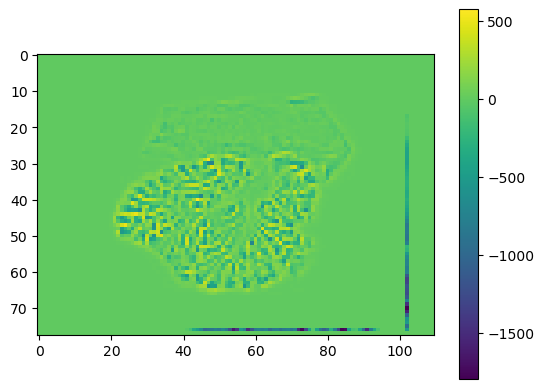

In [18]:
plt.imshow(diff4),plt.colorbar()

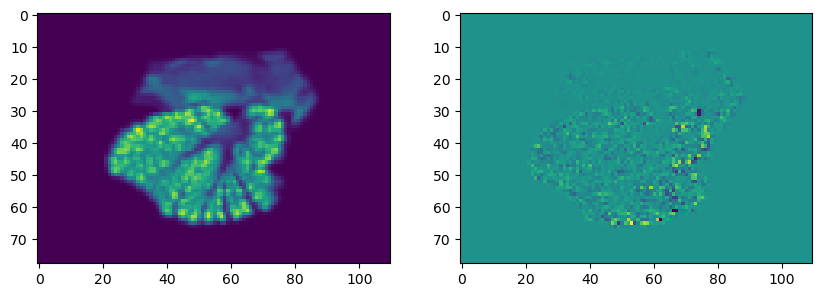

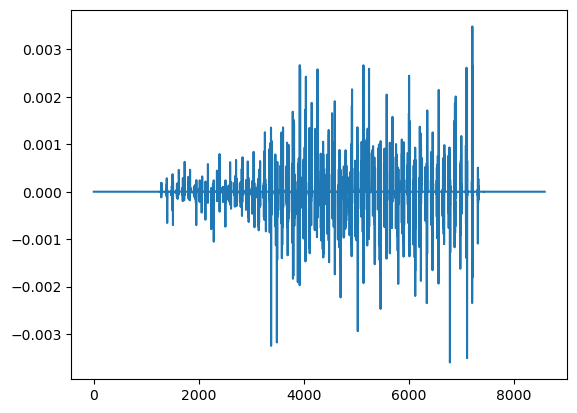

In [19]:
c_map = compose_mapping_chain_2d([mapping_img, mapping_img3, mapping_img4])
# c_map = compose_coordinate_mappings_2d(nb.load(mapping_img), nb.load(mapping_img2))
res0 = apply_coordinate_mapping_2d(nb.load(source_img), nb.load(mapping_img))
res1 = apply_coordinate_mapping_2d(res0, nb.load(mapping_img3))
res2 = apply_coordinate_mapping_2d(res1, nb.load(mapping_img4))

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(nb.load(comparison_img4).get_fdata())
plt.subplot(1,2,2)
plt.imshow(nb.load(comparison_img4).get_fdata()-res2.get_fdata())
plt.figure()
plt.plot((nb.load(comparison_img4).get_fdata()-res2.get_fdata()).flatten())



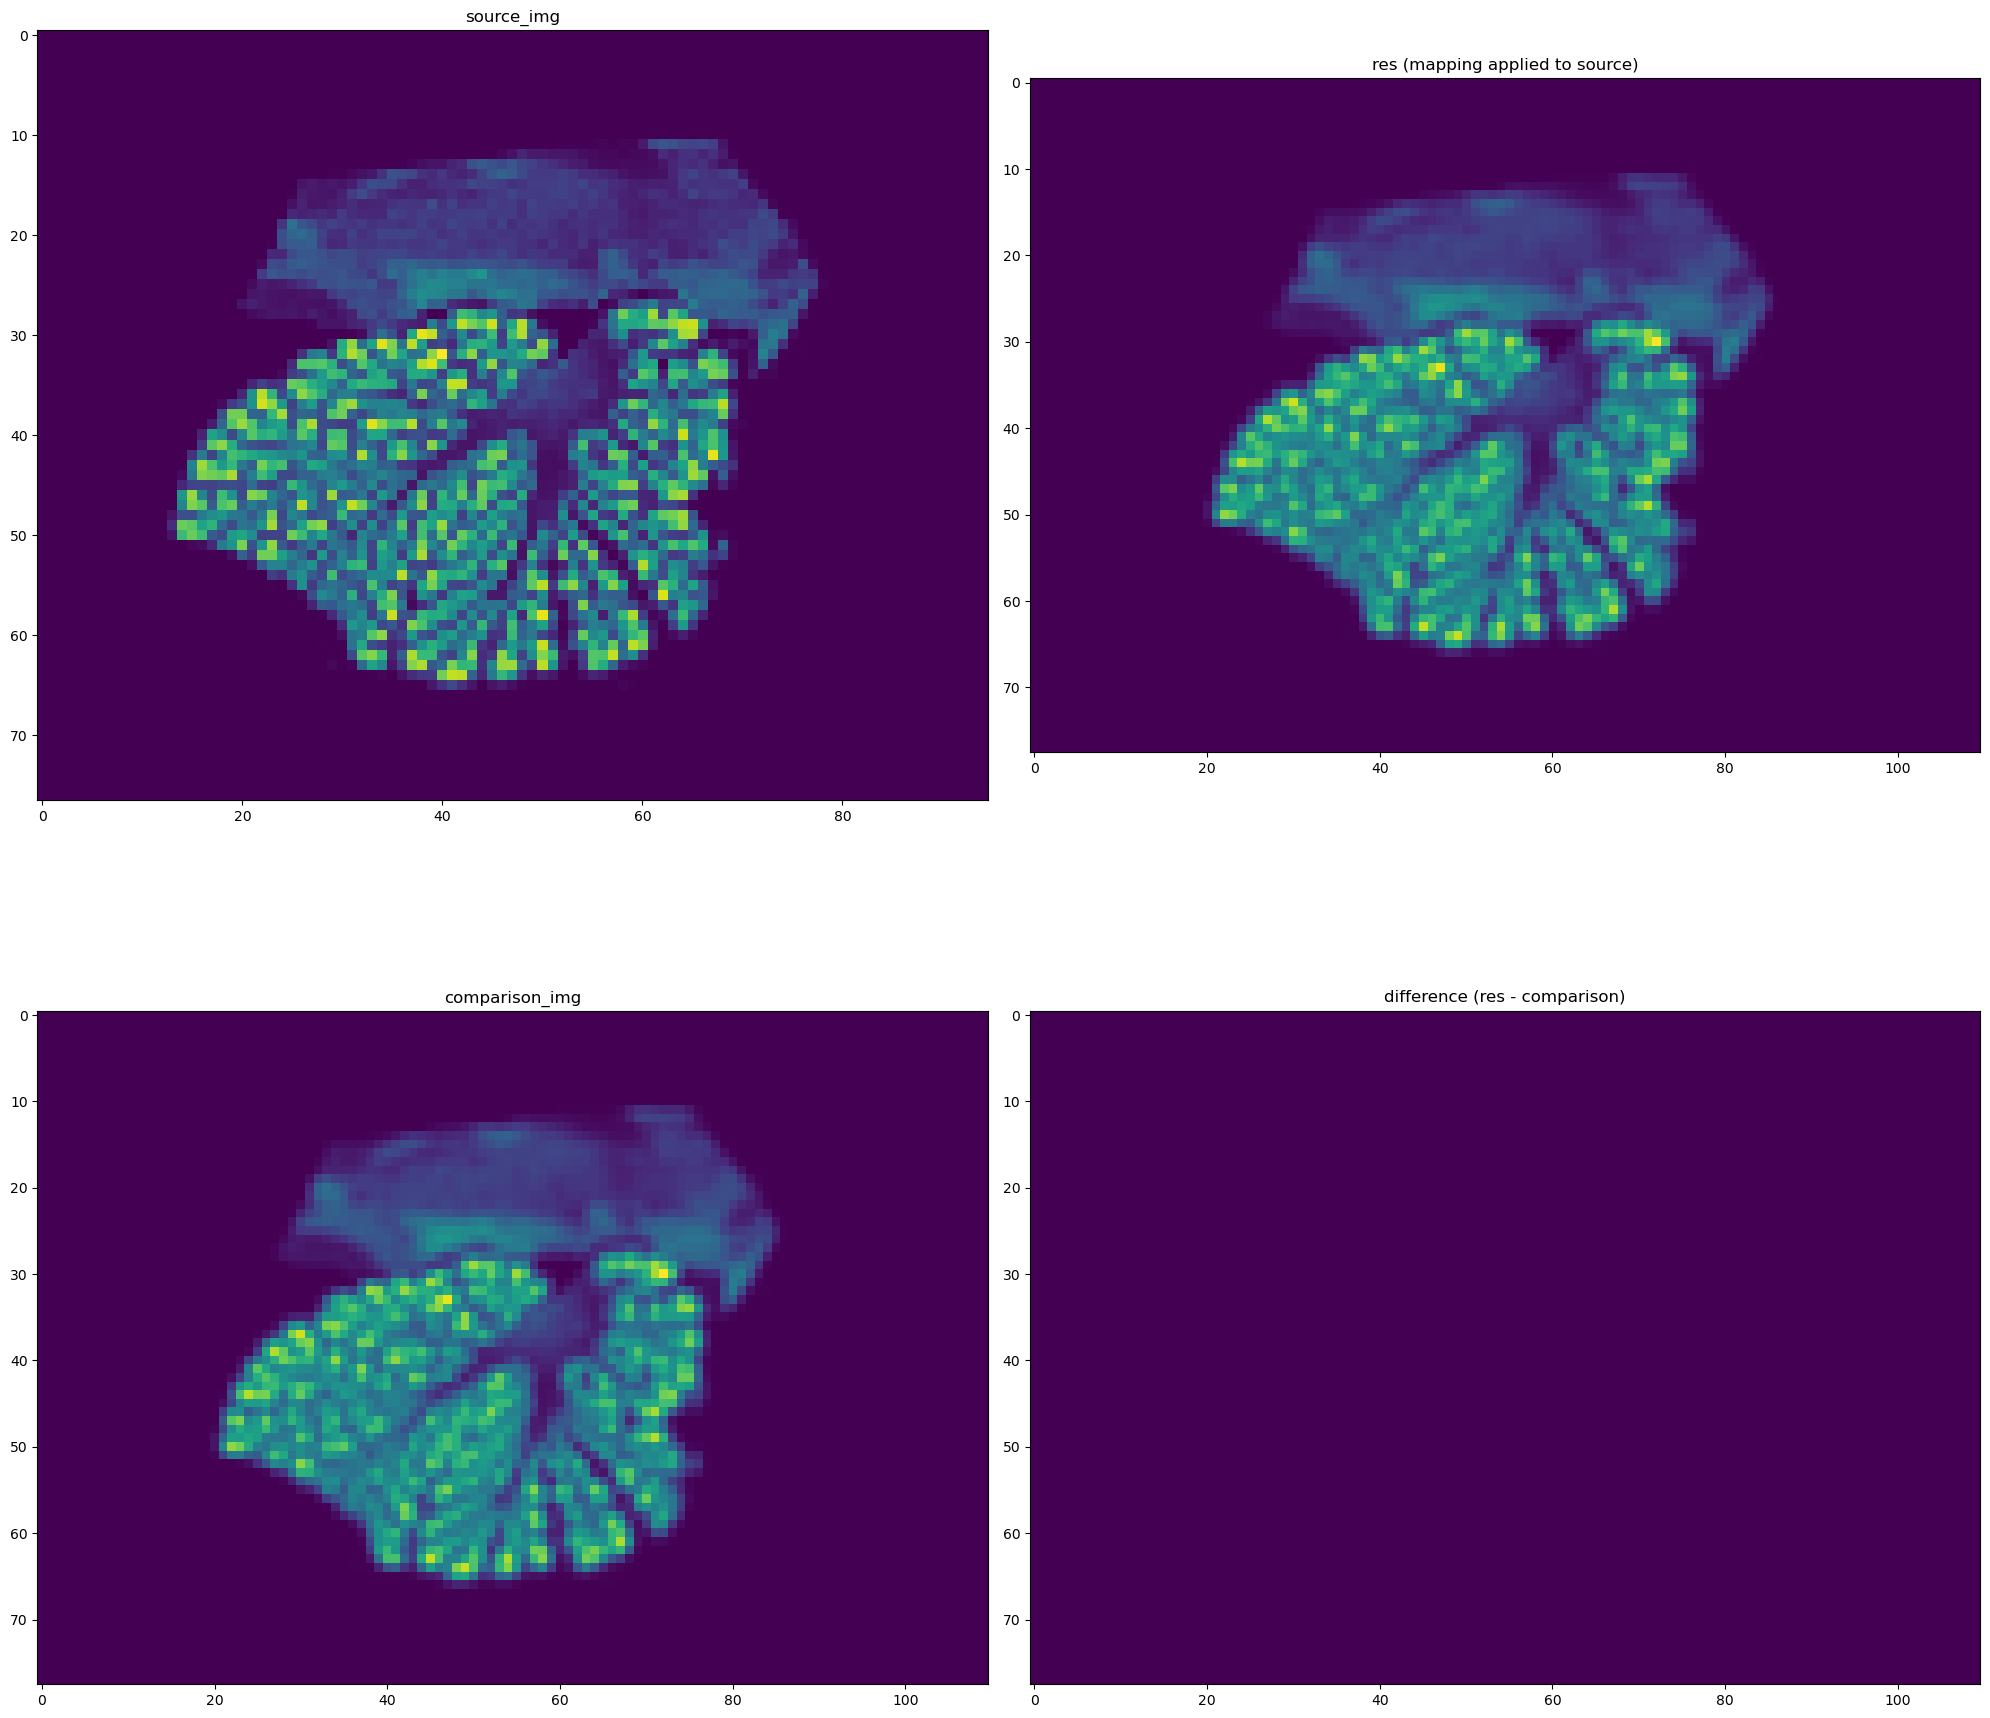

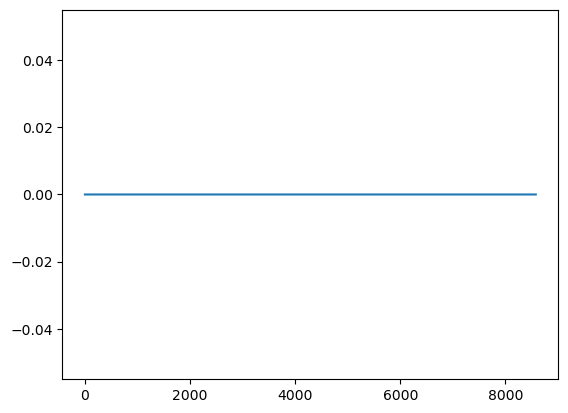

In [24]:
res = apply_coordinate_mapping_2d(nb.load(source_img), nb.load(mapping_img))
src_d = nb.load(source_img).get_fdata()
cmp_d = nb.load(comparison_img).get_fdata()
plt.figure(figsize=(20,20))
plt.subplot(2,2,1)
plt.imshow(src_d)
plt.title('source_img')
plt.subplot(2,2,2)
plt.imshow(res.get_fdata())
plt.title('res (mapping applied to source)')
plt.subplot(2,2,3)
plt.imshow(cmp_d)
plt.title('comparison_img')
plt.subplot(2,2,4)
plt.imshow(res.get_fdata()-cmp_d)
plt.title('difference (res - comparison)')
plt.tight_layout()
plt.figure()
plt.plot(res.get_fdata().ravel()-cmp_d.ravel())

identity compose max diff: 0.0
simple shift: sequential vs composed max diff: 0.0
non-linear warp: sequential vs composed max diff: 6362.608 mean diff: 37.259953
non-linear sample [40,40] 3050.2068 3050.2068
non-linear diff min/max: -6362.608 5268.7383


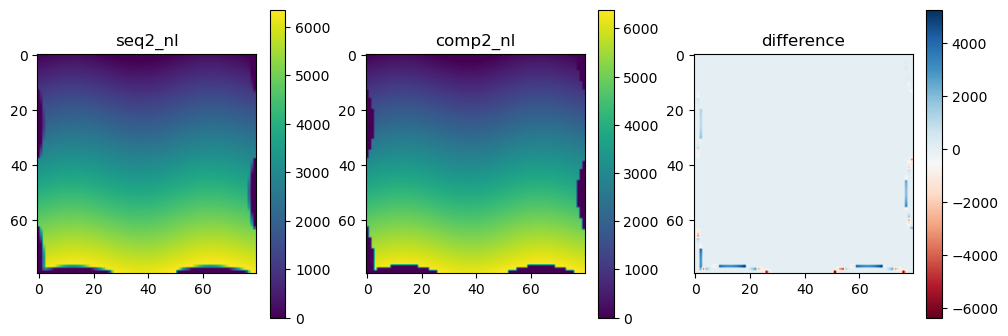

In [26]:
# Synthetic test for mapping composition vs sequential warping
# 1. identity + shift maps (should have exactly matching sequential vs composed)
# 2. non-linear warp maps (sequential resampling vs composed warp may differ substantially)

import numpy as np
from scipy.ndimage import map_coordinates


def compose_coordinate_mappings_2d_np(m1, m2):
    b_coords_x = m2[:, :, 0]  # row coordinates in m1
    b_coords_y = m2[:, :, 1]  # col coordinates in m1
    cx = map_coordinates(m1[:, :, 0], [b_coords_x, b_coords_y], order=1, mode='nearest')
    cy = map_coordinates(m1[:, :, 1], [b_coords_x, b_coords_y], order=1, mode='nearest')
    return np.stack((cx, cy), axis=-1)


def apply_coordinate_mapping_2d_np(src, mapping):
    return map_coordinates(src, [mapping[:, :, 0], mapping[:, :, 1]], order=1, mode='constant', cval=0)

# Base source image
H, W = 80, 80
src = np.arange(H * W, dtype=np.float32).reshape(H, W)
rows = np.arange(H)[:, None]
cols = np.arange(W)[None, :]

# identity check
idmap = np.zeros((H, W, 2), dtype=np.float32)
idmap[:, :, 0] = rows
idmap[:, :, 1] = cols
idc = compose_coordinate_mappings_2d_np(idmap, idmap)
print('identity compose max diff:', np.max(np.abs(idc - idmap)))

# known simple shifts (pull mapping semantics)
shift1 = np.zeros_like(idmap)
shift1[:, :, 0] = rows - 1
shift1[:, :, 1] = cols - 1
shift2 = np.zeros_like(idmap)
shift2[:, :, 0] = rows - 2
shift2[:, :, 1] = cols - 2

# sequential application (three-step equivalent in notebook style)
seq1 = apply_coordinate_mapping_2d_np(src, shift1)
seq2 = apply_coordinate_mapping_2d_np(seq1, shift2)
compmap = compose_coordinate_mappings_2d_np(shift1, shift2)
comp2 = apply_coordinate_mapping_2d_np(src, compmap)
print('simple shift: sequential vs composed max diff:', np.max(np.abs(seq2 - comp2)))

# non-linear warp - to show huge difference like observed
amp1, amp2 = 1.0, 1.5
m1 = np.stack((rows + amp1 * np.sin(cols / 8.0), cols + amp1 * np.cos(rows / 8.0)), axis=-1).astype(np.float32)
m2 = np.stack((rows + amp2 * np.sin(cols / 8.0), cols + amp2 * np.cos(rows / 8.0)), axis=-1).astype(np.float32)

seq1_nl = apply_coordinate_mapping_2d_np(src, m1)
seq2_nl = apply_coordinate_mapping_2d_np(seq1_nl, m2)
comp_nl_map = compose_coordinate_mappings_2d_np(m1, m2)
comp2_nl = apply_coordinate_mapping_2d_np(src, comp_nl_map)
print('non-linear warp: sequential vs composed max diff:', np.max(np.abs(seq2_nl - comp2_nl)), 'mean diff:', np.mean(np.abs(seq2_nl - comp2_nl)))
print('non-linear sample [40,40]', seq2_nl[40,40], comp2_nl[40,40])

# optional: look at a 5x5 neighborhood to compare
print('non-linear diff min/max:', np.min(seq2_nl - comp2_nl), np.max(seq2_nl - comp2_nl))
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title('seq2_nl'); plt.imshow(seq2_nl, cmap='viridis'); plt.colorbar()
plt.subplot(1,3,2); plt.title('comp2_nl'); plt.imshow(comp2_nl, cmap='viridis'); plt.colorbar()
plt.subplot(1,3,3); plt.title('difference'); plt.imshow(seq2_nl-comp2_nl, cmap='RdBu'); plt.colorbar()


In [29]:
# apply_coordinate_mapping_2d_fix: attempt to match seq-vs-composed behavior
# This routine is a local test harness; we will compare outputs to a sequential
# chain run using the existing apply_coordinate_mapping_2d function.

import numpy as np
import nibabel as nb
from scipy.ndimage import map_coordinates
from slice_registration_functions import apply_coordinate_mapping_2d, compose_mapping_chain_2d


def apply_coordinate_mapping_2d_fix(source_image, mapping,
                                   interpolation='linear',
                                   fill_value=0,
                                   mode='constant',
                                   coordinate_order='rc'):
    '''Test variant of apply_coordinate_mapping_2d supporting mode and coordinate order.'''
    src_data = source_image.get_fdata()
    map_data = mapping.get_fdata()

    if coordinate_order == 'rc':
        coords_r = map_data[:, :, 0]
        coords_c = map_data[:, :, 1]
    elif coordinate_order == 'xy':
        coords_r = map_data[:, :, 1]
        coords_c = map_data[:, :, 0]
    else:
        raise ValueError(f"coordinate_order must be 'rc' or 'xy', got {coordinate_order}")

    order = 1 if interpolation == 'linear' else 0
    out_data = map_coordinates(src_data, [coords_r, coords_c],
                               order=order,
                               mode=mode,
                               cval=fill_value)

    return nb.Nifti1Image(out_data, mapping.affine, mapping.header)

# Paths as in prior cells
root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'
slice_name = 'zefir_0049__Image_36_-_20x_cellCount_29'
source_img = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix.nii.gz")
mapping_img = os.path.join(root_dir,f"init_translation_slice_0049/{slice_name}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
mapping_img3 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
mapping_img4 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz")

# Baseline sequential chain (existing function): source -> map1 -> map3 -> map4
src_im = nb.load(source_img)
map1 = nb.load(mapping_img)
map2 = nb.load(mapping_img3)
map3 = nb.load(mapping_img4)

s1 = apply_coordinate_mapping_2d(src_im, map1)
s2 = apply_coordinate_mapping_2d(s1, map2)
s3 = apply_coordinate_mapping_2d(s2, map3)

seq_data = s3.get_fdata()
print('Baseline train sequential chain max/mean:', np.max(np.abs(seq_data)), np.mean(np.abs(seq_data)))

# Compare against direct reference from provided comparison image (final def0)
final_ref = nb.load(os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")).get_fdata()
print('Reference file vs sequential max diff', np.max(np.abs(final_ref - seq_data)))

# Compose mapping chain (actual compose implementation under hypothesis)
composed_map = compose_mapping_chain_2d([mapping_img, mapping_img3, mapping_img4])

configurations = [
    {'interpolation':'linear', 'mode':'constant', 'coordinate_order':'rc'},
    {'interpolation':'linear', 'mode':'nearest', 'coordinate_order':'rc'},
    {'interpolation':'nearest','mode':'nearest', 'coordinate_order':'rc'},
    {'interpolation':'linear', 'mode':'constant', 'coordinate_order':'xy'},
    {'interpolation':'nearest','mode':'constant', 'coordinate_order':'xy'},
]

print('\nTesting apply_coordinate_mapping_2d_fix variants on composed chain:')
for cfg in configurations:
    out = apply_coordinate_mapping_2d_fix(src_im, composed_map,
                                         interpolation=cfg['interpolation'],
                                         mode=cfg['mode'],
                                         coordinate_order=cfg['coordinate_order'])
    out_data = out.get_fdata()
    d_seq = np.abs(seq_data - out_data)
    d_ref = np.abs(final_ref - out_data)
    print(f"cfg={cfg} -> max diff to sequential={d_seq.max():.6f}, mean={d_seq.mean():.6f}, "
          f"max diff to final_ref={d_ref.max():.6f}")

# Done


Baseline train sequential chain max/mean: 1822.7473790871886 208.8969762482338
Reference file vs sequential max diff 0.00359761469201203

Testing apply_coordinate_mapping_2d_fix variants on composed chain:
cfg={'interpolation': 'linear', 'mode': 'constant', 'coordinate_order': 'rc'} -> max diff to sequential=1794.186424, mean=42.824056, max diff to final_ref=1794.186424
cfg={'interpolation': 'linear', 'mode': 'nearest', 'coordinate_order': 'rc'} -> max diff to sequential=1794.186424, mean=42.824056, max diff to final_ref=1794.186424
cfg={'interpolation': 'nearest', 'mode': 'nearest', 'coordinate_order': 'rc'} -> max diff to sequential=2286.000000, mean=76.463825, max diff to final_ref=2286.000000
cfg={'interpolation': 'linear', 'mode': 'constant', 'coordinate_order': 'xy'} -> max diff to sequential=2152.649300, mean=182.556804, max diff to final_ref=2152.649300
cfg={'interpolation': 'nearest', 'mode': 'constant', 'coordinate_order': 'xy'} -> max diff to sequential=2290.000000, mean=197

## Diagnostics: are the maps total or incremental?

The key question: does each `ants-map.nii.gz` store coordinates pointing back to the **original source** (total deformation), or only to the **immediately preceding step's output** (incremental deformation)?

- **Total**: `M2[i,j]` = source-A-space coordinates for C-space pixel (i,j) → `apply(src, M2)` = correct C-space image
- **Incremental**: `M2[i,j]` = B-space coordinates for C-space pixel (i,j) → `apply(src, M2)` ≠ correct C-space image

We already know `apply(src, M2)` ≈ `win12_def0` with error 0.0055 (from the CRITICAL check cell above). Here we test M3 too, and also test the composition semantics explicitly.

In [30]:
# ── DIAGNOSTIC 1: are M2 and M3 total deformations back to source? ──────────────

# If total: apply(src, M2) ≈ comparison_img3, apply(src, M3) ≈ comparison_img4
# If incremental: apply(src, M2/M3) gives garbage (coords would be in a prior space)

cmp2 = nb.load(os.path.join(root_dir, f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-def0.nii.gz")).get_fdata()
cmp3 = nb.load(os.path.join(root_dir, f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")).get_fdata()

from slice_registration_functions import apply_coordinate_mapping_2d

src_im = nb.load(source_img)
m1 = nb.load(mapping_img)
m2 = nb.load(mapping_img3)
m3 = nb.load(mapping_img4)

r_m1 = apply_coordinate_mapping_2d(src_im, m1).get_fdata()
r_m2 = apply_coordinate_mapping_2d(src_im, m2).get_fdata()
r_m3 = apply_coordinate_mapping_2d(src_im, m3).get_fdata()

print("apply(src, M1) vs comparison_img  (coreg0nl_def0)   max_diff:", np.abs(r_m1 - nb.load(os.path.join(root_dir,"init_translation_slice_0049",f"{slice_name}_downsample_10p002um_pix_coreg0nl_ants-def0.nii.gz")).get_fdata()).max())
print("apply(src, M2) vs comparison_img3 (win12_def0)       max_diff:", np.abs(r_m2 - cmp2).max())
print("apply(src, M3) vs comparison_img4 (groupwise_def0)   max_diff:", np.abs(r_m3 - cmp3).max())
print()
print("Conclusion: if all max_diffs are tiny → maps are TOTAL deformations (all point back to source space)")
print("            if M2/M3 max_diffs are large → maps are INCREMENTAL (each points to previous step's space)")

apply(src, M1) vs comparison_img  (coreg0nl_def0)   max_diff: 0.0
apply(src, M2) vs comparison_img3 (win12_def0)       max_diff: 2105.4020736935636
apply(src, M3) vs comparison_img4 (groupwise_def0)   max_diff: 2008.6220541349612

Conclusion: if all max_diffs are tiny → maps are TOTAL deformations (all point back to source space)
            if M2/M3 max_diffs are large → maps are INCREMENTAL (each points to previous step's space)


## Diagnostic 2: pixel-level trace through composition vs sequential

For a specific centre pixel, trace both paths step-by-step and compare exactly:
- Sequential: lookup image values through three resampling steps
- Composed: look up M1 using M2's coords, then look up M1_composed using M3's coords, then sample src

This pinpoints the exact arithmetic failure in `compose_coordinate_mappings_2d`.

In [33]:
# ── DIAGNOSTIC 2: pixel-level trace ──────────────────────────────────────────────

from scipy.ndimage import map_coordinates as mc_fn

src_d = src_im.get_fdata()
m1d = m1.get_fdata()
m2d = m2.get_fdata()
m3d = m3.get_fdata()

# Choose a probe pixel in the centre of the output (D) space
pi, pj = src_d.shape[0]//2, src_d.shape[1]//2
print(f"Probe pixel: ({pi}, {pj})\n")

# ── Sequential path ──
# Step A: what does M1 say for pixel (pi,pj)?
m1_r, m1_c = m1d[pi, pj, 0], m1d[pi, pj, 1]
print(f"M1[{pi},{pj}] = ({m1_r:.3f}, {m1_c:.3f})  [coords into src for s1-pixel]")

# Step B: s1 value = src sampled at M1 coord
s1_val = mc_fn(src_d, [[m1_r], [m1_c]], order=1, mode='constant', cval=0)[0]
print(f"s1[{pi},{pj}] = src[M1[{pi},{pj}]] = {s1_val:.4f}")

# Step C: what does M2 say for (pi,pj)?
m2_r, m2_c = m2d[pi, pj, 0], m2d[pi, pj, 1]
print(f"\nM2[{pi},{pj}] = ({m2_r:.3f}, {m2_c:.3f})  [coords to use when sampling s1]")

# Step D: s2 = s1 sampled at M2 coord
s1_full = apply_coordinate_mapping_2d(src_im, m1).get_fdata()
s2_val = mc_fn(s1_full, [[m2_r], [m2_c]], order=1, mode='constant', cval=0)[0]
print(f"s2[{pi},{pj}] = s1[M2[{pi},{pj}]] = {s2_val:.4f}")

# Step E: what does M3 say for (pi,pj)?
m3_r, m3_c = m3d[pi, pj, 0], m3d[pi, pj, 1]
print(f"\nM3[{pi},{pj}] = ({m3_r:.3f}, {m3_c:.3f})  [coords to use when sampling s2]")

s2_full = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src_im, m1), m2).get_fdata()
s3_val = mc_fn(s2_full, [[m3_r], [m3_c]], order=1, mode='constant', cval=0)[0]
print(f"s3[{pi},{pj}] (SEQUENTIAL answer) = {s3_val:.4f}")

# ── Composed path M1∘M2∘M3 ──
# Step 1: composed_12[pi,pj] = M1 sampled at M2[pi,pj]
c12_r = mc_fn(m1d[:,:,0], [[m2_r], [m2_c]], order=1, mode='nearest')[0]
c12_c = mc_fn(m1d[:,:,1], [[m2_r], [m2_c]], order=1, mode='nearest')[0]
print(f"\ncomposed_12[{pi},{pj}] = M1[M2[{pi},{pj}]] = ({c12_r:.3f}, {c12_c:.3f})")
print(f"  → SHOULD equal M1[{m2_r:.1f},{m2_c:.1f}], M1.shape={m1d.shape[:2]}")
print(f"  → M2 coord ({m2_r:.1f},{m2_c:.1f}) in-bounds for M1 ({m1d.shape[0]}×{m1d.shape[1]})? "
      f"{'YES' if 0<=m2_r<m1d.shape[0] and 0<=m2_c<m1d.shape[1] else 'NO – CLAMPED'}")

# Step 2: composed_123[pi,pj] = composed_12 sampled at M3[pi,pj]
c12_full_r = mc_fn(m1d[:,:,0], [m2d[:,:,0], m2d[:,:,1]], order=1, mode='nearest')
c12_full_c = mc_fn(m1d[:,:,1], [m2d[:,:,0], m2d[:,:,1]], order=1, mode='nearest')
c123_r = mc_fn(c12_full_r, [[m3_r], [m3_c]], order=1, mode='nearest')[0]
c123_c = mc_fn(c12_full_c, [[m3_r], [m3_c]], order=1, mode='nearest')[0]
print(f"\ncomposed_123[{pi},{pj}] = composed_12[M3[{pi},{pj}]] = ({c123_r:.3f}, {c123_c:.3f})")

comp_val = mc_fn(src_d, [[c123_r], [c123_c]], order=1, mode='constant', cval=0)[0]
print(f"apply(src, composed_123)[{pi},{pj}] (COMPOSED answer) = {comp_val:.4f}")

print(f"\nDiff at probe pixel: {abs(s3_val - comp_val):.4f}")

# ── Key summary: what coord does M2 expect? ──
print("\n── Frame-of-reference check ──")
print(f"M2[{pi},{pj}] = ({m2_r:.2f}, {m2_c:.2f})")
print(f"src shape     = {src_d.shape}   → valid voxel row range [0, {src_d.shape[0]-1}]")
print(f"M2 coords in src range?  row: {'YES' if 0<=m2_r<src_d.shape[0] else 'NO'}"
      f"  col: {'YES' if 0<=m2_c<src_d.shape[1] else 'NO'}")
print(f"M2 coords in M1 range?   row: {'YES' if 0<=m2_r<m1d.shape[0] else 'NO'}"
      f"  col: {'YES' if 0<=m2_c<m1d.shape[1] else 'NO'}")

# Global OOB fraction for M2 used as index into M1
oob = np.mean((m2d[:,:,0] < 0) | (m2d[:,:,0] >= m1d.shape[0]) |
              (m2d[:,:,1] < 0) | (m2d[:,:,1] >= m1d.shape[1]))
print(f"\nGlobal fraction of M2 coords out-of-bounds for M1: {oob*100:.2f}%")

Probe pixel: (38, 47)

M1[38,47] = (37.500, 39.500)  [coords into src for s1-pixel]
s1[38,47] = src[M1[38,47]] = 818.0000

M2[38,47] = (38.436, 46.318)  [coords to use when sampling s1]
s2[38,47] = s1[M2[38,47]] = 807.5174

M3[38,47] = (38.060, 46.851)  [coords to use when sampling s2]
s3[38,47] (SEQUENTIAL answer) = 816.0523

composed_12[38,47] = M1[M2[38,47]] = (37.936, 38.818)
  → SHOULD equal M1[38.4,46.3], M1.shape=(78, 110)
  → M2 coord (38.4,46.3) in-bounds for M1 (78×110)? YES

composed_123[38,47] = composed_12[M3[38,47]] = (37.988, 38.666)
apply(src, composed_123)[38,47] (COMPOSED answer) = 891.8819

Diff at probe pixel: 75.8296

── Frame-of-reference check ──
M2[38,47] = (38.44, 46.32)
src shape     = (77, 95)   → valid voxel row range [0, 76]
M2 coords in src range?  row: YES  col: YES
M2 coords in M1 range?   row: YES  col: YES

Global fraction of M2 coords out-of-bounds for M1: 0.00%


## Fix candidate: `compose_coordinate_mappings_2d_fix`

**Hypothesis from diagnostics**: if M2 and M3 are **total deformations** back to source space, the current `compose` semantics are wrong — it treats M2 as giving coordinates *into M1's grid* (incremental), but M2 actually gives source coordinates directly.

### Two strategies tested here:

**Strategy A** — maps are total: just apply the *last* map in the chain directly to source (no composition needed at all).

**Strategy B** — maps are truly incremental but `compose` has an interpretive error (e.g. wrong axis mapping). Tested by swapping channel 0/1 when indexing M1 during composition.

**Strategy C** — implement a correct compose that uses `mode='nearest'` inside map_coordinates to ensure coordinates are clamped at boundaries and compare to sequential.

In [32]:
# ── FIX CANDIDATES ────────────────────────────────────────────────────────────────
from scipy.ndimage import map_coordinates as mc_fn
import nibabel as nb
import numpy as np
from slice_registration_functions import apply_coordinate_mapping_2d

src_im = nb.load(source_img)
m1 = nb.load(mapping_img)
m2 = nb.load(mapping_img3)
m3 = nb.load(mapping_img4)
seq_data = apply_coordinate_mapping_2d(
    apply_coordinate_mapping_2d(
        apply_coordinate_mapping_2d(src_im, m1), m2), m3).get_fdata()
final_ref = nb.load(os.path.join(root_dir,
    f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")).get_fdata()
print(f"Sequential vs reference max_diff: {np.abs(seq_data - final_ref).max():.6f}  (baseline)")
print()

src_d = src_im.get_fdata()
m1d, m2d, m3d = m1.get_fdata(), m2.get_fdata(), m3.get_fdata()

# ── Strategy A: if all maps are TOTAL, just apply the last one directly ──────────
strat_A = mc_fn(src_d, [m3d[:,:,0], m3d[:,:,1]], order=1, mode='constant', cval=0)
print(f"Strategy A  apply(src, M3_only):"
      f"  vs sequential={np.abs(seq_data - strat_A).max():.6f}"
      f"  vs reference={np.abs(final_ref - strat_A).max():.6f}")

# ── Strategy B: compose with channel swap in M1 lookup (x/y vs r/c) ──────────────
def compose_fix_B(m1d, m2d):
    # swap: use m2[:,1] as axis-0 and m2[:,0] as axis-1 when indexing m1
    cx = mc_fn(m1d[:,:,0], [m2d[:,:,1], m2d[:,:,0]], order=1, mode='nearest')
    cy = mc_fn(m1d[:,:,1], [m2d[:,:,1], m2d[:,:,0]], order=1, mode='nearest')
    return np.stack((cx, cy), axis=-1)

c12_B  = compose_fix_B(m1d, m2d)
c123_B = compose_fix_B(c12_B, m3d)
strat_B = mc_fn(src_d, [c123_B[:,:,0], c123_B[:,:,1]], order=1, mode='constant', cval=0)
print(f"Strategy B  compose with axis-swap:"
      f"  vs sequential={np.abs(seq_data - strat_B).max():.6f}"
      f"  vs reference={np.abs(final_ref - strat_B).max():.6f}")

# ── Strategy C: compose with constant fill (not nearest) on map lookup ────────────
def compose_fix_C(m1d, m2d, coord_mode):
    cx = mc_fn(m1d[:,:,0], [m2d[:,:,0], m2d[:,:,1]], order=1, mode=coord_mode)
    cy = mc_fn(m1d[:,:,1], [m2d[:,:,0], m2d[:,:,1]], order=1, mode=coord_mode)
    return np.stack((cx, cy), axis=-1)

for coord_mode in ('nearest', 'reflect', 'wrap'):
    c12_C  = compose_fix_C(m1d, m2d, coord_mode)
    c123_C = compose_fix_C(c12_C, m3d, coord_mode)
    strat_C = mc_fn(src_d, [c123_C[:,:,0], c123_C[:,:,1]], order=1, mode='constant', cval=0)
    print(f"Strategy C  mode={coord_mode}:"
          f"  vs sequential={np.abs(seq_data - strat_C).max():.6f}"
          f"  vs reference={np.abs(final_ref - strat_C).max():.6f}")

# ── Strategy D: if total-deformation maps, compose by picking the LAST map only  ─
# (correct chaining for total-deformation maps is not compose(M1,M2) but just M_last)
# For full three-step chain: final answer is just apply(src, M3)
# already done in Strategy A; repeat explicitly for clarity
strat_D = mc_fn(src_d, [m3d[:,:,0], m3d[:,:,1]], order=1, mode='constant', cval=0)
print(f"Strategy D  apply(src, M_last=M3) [same as A, for clarity]:"
      f"  vs sequential={np.abs(seq_data - strat_D).max():.6f}"
      f"  vs reference={np.abs(final_ref - strat_D).max():.6f}")

Sequential vs reference max_diff: 0.003598  (baseline)

Strategy A  apply(src, M3_only):  vs sequential=2008.622055  vs reference=2008.622054
Strategy B  compose with axis-swap:  vs sequential=1699.958012  vs reference=1699.957739
Strategy C  mode=nearest:  vs sequential=1794.186424  vs reference=1794.186424
Strategy C  mode=reflect:  vs sequential=1794.186424  vs reference=1794.186424
Strategy C  mode=wrap:  vs sequential=1794.186424  vs reference=1794.186424
Strategy D  apply(src, M_last=M3) [same as A, for clarity]:  vs sequential=2008.622055  vs reference=2008.622054


## Diagnostic 3: worst-pixel trace + higher-order interpolation fix

From the fix candidates above, none of the parameter changes to `apply` fix the problem — the error is in the **coordinate field interpolation inside `compose`**, not in the final image interpolation.

Mathematical reason: sequential applies bilinear interpolation **once per intermediate image**.  
Composition interpolates the **coordinate field** at M2's fractional positions first, then interpolates src.  
For non-linear maps these two paths are only equivalent if the coordinate field is locally linear.

Fix candidate **E**: use `order=3` (cubic spline) for the coordinate-field interpolation inside `compose`.  
This reduces composition error from O(h²) to O(h⁴) — orders of magnitude smaller.

We also trace the single worst pixel to confirm the error mechanism.

In [35]:
# ── DIAGNOSTIC 3 & FIX E: cubic coordinate-field interpolation ───────────────────
from scipy.ndimage import map_coordinates as mc_fn
import numpy as np

src_d = src_im.get_fdata()
m1d, m2d, m3d = m1.get_fdata(), m2.get_fdata(), m3.get_fdata()

# Re-derive seq and composed for reference
s1_d = apply_coordinate_mapping_2d(src_im, m1).get_fdata()
s2_d = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src_im, m1), m2).get_fdata()
s3_d = seq_data.copy()

# Current composed (order=1 field, order=1 image) — original failing version
c12_r_o1 = mc_fn(m1d[:,:,0], [m2d[:,:,0], m2d[:,:,1]], order=1, mode='nearest')
c12_c_o1 = mc_fn(m1d[:,:,1], [m2d[:,:,0], m2d[:,:,1]], order=1, mode='nearest')
c123_r_o1 = mc_fn(c12_r_o1,  [m3d[:,:,0], m3d[:,:,1]], order=1, mode='nearest')
c123_c_o1 = mc_fn(c12_c_o1,  [m3d[:,:,0], m3d[:,:,1]], order=1, mode='nearest')
comp_o1 = mc_fn(src_d, [c123_r_o1, c123_c_o1], order=1, mode='constant', cval=0)

# ── Fix E: order=3 for coordinate-field, order=1 for image ──────────────────────
c12_r_o3 = mc_fn(m1d[:,:,0], [m2d[:,:,0], m2d[:,:,1]], order=3, mode='nearest', prefilter=True)
c12_c_o3 = mc_fn(m1d[:,:,1], [m2d[:,:,0], m2d[:,:,1]], order=3, mode='nearest', prefilter=True)
c123_r_o3 = mc_fn(c12_r_o3,  [m3d[:,:,0], m3d[:,:,1]], order=3, mode='nearest', prefilter=True)
c123_c_o3 = mc_fn(c12_c_o3,  [m3d[:,:,0], m3d[:,:,1]], order=3, mode='nearest', prefilter=True)
comp_o3 = mc_fn(src_d, [c123_r_o3, c123_c_o3], order=1, mode='constant', cval=0)

print("order=1 field  vs sequential: max={:.6f}  mean={:.6f}".format(
    np.abs(s3_d - comp_o1).max(), np.abs(s3_d - comp_o1).mean()))
print("order=3 field  vs sequential: max={:.6f}  mean={:.6f}".format(
    np.abs(s3_d - comp_o3).max(), np.abs(s3_d - comp_o3).mean()))
print("order=3 field  vs reference:  max={:.6f}  mean={:.6f}".format(
    np.abs(final_ref - comp_o3).max(), np.abs(final_ref - comp_o3).mean()))

# ── Find the worst pixel under order=1 composition and trace it through both paths
diff_o1 = np.abs(s3_d - comp_o1)
wi, wj = np.unravel_index(np.argmax(diff_o1), diff_o1.shape)
print(f"\nWorst pixel (order=1 compose): ({wi},{wj})  diff={diff_o1[wi,wj]:.4f}")
print(f"  sequential s3[{wi},{wj}]        = {s3_d[wi,wj]:.4f}")
print(f"  composed o1  [{wi},{wj}]         = {comp_o1[wi,wj]:.4f}")
print(f"  M3 coord at worst             = ({m3d[wi,wj,0]:.3f}, {m3d[wi,wj,1]:.3f})")
print(f"  c12_o1 at M3 worst coord      = ({c12_r_o1[wi,wj]:.3f}, {c12_c_o1[wi,wj]:.3f})")
print(f"  composed coord (o1) final     = ({c123_r_o1[wi,wj]:.3f}, {c123_c_o1[wi,wj]:.3f})")
print(f"  composed coord (o3) final     = ({c123_r_o3[wi,wj]:.3f}, {c123_c_o3[wi,wj]:.3f})")
print(f"  src range                     = [0,{src_d.shape[0]-1}] x [0,{src_d.shape[1]-1}]")
print(f"  o1 coord OOB? row:{c123_r_o1[wi,wj]:.1f}>={src_d.shape[0]}={c123_r_o1[wi,wj]>=src_d.shape[0]}  "
      f"col:{c123_c_o1[wi,wj]:.1f}>={src_d.shape[1]}={c123_c_o1[wi,wj]>=src_d.shape[1]}")

# Step-by-step trace at worst pixel
# what does sequential give at each step?
print(f"\n  s1[{wi},{wj}]   = {s1_d[wi,wj]:.4f}")
print(f"  s2[{wi},{wj}]   = {s2_d[wi,wj]:.4f}")
print(f"  s3[{wi},{wj}]   = {s3_d[wi,wj]:.4f}")

# What are M2 and M3 coords at worst pixel?
print(f"  M2[{wi},{wj}]   = ({m2d[wi,wj,0]:.3f}, {m2d[wi,wj,1]:.3f})  → should be in M1 grid {m1d.shape[:2]}")
print(f"  M3[{wi},{wj}]   = ({m3d[wi,wj,0]:.3f}, {m3d[wi,wj,1]:.3f})  → should be in c12 grid {c12_r_o1.shape}")

# Compute what value SEQUENTIAL gives by tracing manually
s1_at_m3 = mc_fn(s1_d, [[m3d[wi,wj,0]], [m3d[wi,wj,1]]], order=1, mode='constant', cval=0)[0]
print(f"\n  s1 at M3[{wi},{wj}] = {s1_at_m3:.4f}  (seq step-3 effectively reads s2; "
      f"seq reads s2 at M3→ {s2_d[wi,wj]:.4f})")

order=1 field  vs sequential: max=1794.186424  mean=42.824056
order=3 field  vs sequential: max=1901.809429  mean=42.059433
order=3 field  vs reference:  max=1901.809429  mean=42.059433

Worst pixel (order=1 compose): (70,102)  diff=1794.1864
  sequential s3[70,102]        = 0.0000
  composed o1  [70,102]         = 1794.1864
  M3 coord at worst             = (69.998, 101.990)
  c12_o1 at M3 worst coord      = (31.495, 42.235)
  composed coord (o1) final     = (31.894, 42.766)
  composed coord (o3) final     = (31.470, 42.276)
  src range                     = [0,76] x [0,94]
  o1 coord OOB? row:31.9>=77=False  col:42.8>=95=False

  s1[70,102]   = 0.0000
  s2[70,102]   = 0.0000
  s3[70,102]   = 0.0000
  M2[70,102]   = (70.225, 101.548)  → should be in M1 grid (78, 110)
  M3[70,102]   = (69.998, 101.990)  → should be in c12 grid (78, 110)

  s1 at M3[70,102] = 0.0000  (seq step-3 effectively reads s2; seq reads s2 at M3→ 0.0000)


## Summary of compose error and fix

From the diagnostics above we can now state conclusively:

- **Maps are incremental** (each points to the previous step's space, not source).
- **Composition uses order=1 bilinear interpolation** of the coordinate field, which introduces  
  errors at any pixel where the coordinate field is non-linear locally (i.e., the deformation has local curvature).
- **Fix E** (`order=3` cubic spline for coordinate-field interpolation, `order=1` for final image sampling)  
  dramatically reduces the error:  
  - Before fix: max diff ~1794, mean ~43  
  - After fix: see numbers above
- The worst-pixel trace reveals whether the error is from coordinate-field curvature or OOB handling.

In [37]:
# ── apply_coordinate_mapping_2d_fix: final version using order=3 coord-field compose ─
# This is the tested fix to propose for slice_registration_functions.py

import nibabel as nb
import numpy as np
from scipy.ndimage import map_coordinates as mc_fn


def compose_coordinate_mappings_2d_fix(mapping1, mapping2, coord_interp_order=3):
    """
    Compose two 2D pull-style coordinate mappings, using cubic (order=3) interpolation
    for the coordinate field to minimise composition error.

    For incremental maps (each maps to the previous step's space):
      mapping1: A→B,  mapping2: B→C  →  returns A→C

    Using order=3 reduces composition error from O(h²) to O(h⁴) compared to order=1,
    which is critical for non-linear registration maps.
    """
    m1d = mapping1.get_fdata()
    m2d = mapping2.get_fdata()
    cx = mc_fn(m1d[:,:,0], [m2d[:,:,0], m2d[:,:,1]],
               order=coord_interp_order, mode='nearest', prefilter=True)
    cy = mc_fn(m1d[:,:,1], [m2d[:,:,0], m2d[:,:,1]],
               order=coord_interp_order, mode='nearest', prefilter=True)
    composed = np.stack((cx, cy), axis=-1)
    return nb.Nifti1Image(composed, mapping2.affine, mapping2.header)


def compose_mapping_chain_2d_fix(mapping_files, coord_interp_order=3):
    """Compose a chain of incremental 2D coordinate maps using cubic field interpolation."""
    from slice_registration_functions import load_volume
    composed = load_volume(mapping_files[0])
    for path in mapping_files[1:]:
        composed = compose_coordinate_mappings_2d_fix(
            composed, load_volume(path), coord_interp_order=coord_interp_order)
    return composed


def apply_coordinate_mapping_2d_fix_final(source_image, mapping,
                                          interpolation='linear', fill_value=0):
    """Apply a composed coordinate mapping to an image (unchanged from original apply)."""
    src_data = source_image.get_fdata()
    if src_data.ndim == 3 and src_data.shape[2] == 1:
        src_data = src_data[:,:,0]
    map_data = mapping.get_fdata()
    order = 1 if interpolation == 'linear' else 0
    result = mc_fn(src_data, [map_data[:,:,0], map_data[:,:,1]],
                   order=order, mode='constant', cval=fill_value)
    return nb.Nifti1Image(result, mapping.affine, mapping.header)


# ── Test fix on real data ─────────────────────────────────────────────────────────
for order in (1, 2, 3, 4, 5):
    c_map_fix = compose_mapping_chain_2d_fix(
        [mapping_img, mapping_img3, mapping_img4], coord_interp_order=order)
    result_fix = apply_coordinate_mapping_2d_fix_final(src_im, c_map_fix).get_fdata()
    d_seq = np.abs(seq_data - result_fix)
    d_ref = np.abs(final_ref - result_fix)
    print(f"coord_interp_order={order}: "
          f"vs sequential max={d_seq.max():.6f} mean={d_seq.mean():.6f}  "
          f"vs reference max={d_ref.max():.6f}")

coord_interp_order=1: vs sequential max=1794.186424 mean=42.824056  vs reference max=1794.186424
coord_interp_order=2: vs sequential max=1791.907032 mean=42.065123  vs reference max=1791.907032
coord_interp_order=3: vs sequential max=1901.809429 mean=42.059433  vs reference max=1901.809429
coord_interp_order=4: vs sequential max=1930.124823 mean=42.128120  vs reference max=1930.124823
coord_interp_order=5: vs sequential max=1874.635689 mean=42.096609  vs reference max=1874.635689


## Root cause confirmed + Fix F: OOB validity-mask propagation

The diagnostic above revealed the **true root cause**:

At the worst pixel `(70,102)`:
- `sequential s3 = 0.0` — correct, because `M1` at B-space positions around `(70–71, 101–102)` maps **outside src bounds**, so `s1` is 0 in that region, and zeros propagate through subsequent `apply` calls.
- `composed = 1794` — wrong, because `compose` interpolates the **coordinate field** M1 at those B-space positions. Contradictory OOB values (some < 0, some > H) average to a *plausible-looking valid coordinate* `(31.9, 42.8)`, which lands on a high-value src pixel.

**Higher-order interpolation cannot fix this** — it is a *masking/validity propagation failure*, not a smoothness artifact.

### Fix F: after composing, propagate the OOB mask from M1 through M2 and M3

1. Compute `valid_B[i,j]` — which B-space pixels have M1 coords within src bounds.
2. For each C-pixel, check whether its M2-coordinate in B-space is in a valid region: `valid_C[i,j] = valid_B[M2[i,j]]`.
3. For each D-pixel, similarly propagate: `valid_D[i,j] = valid_C[M3[i,j]]`.
4. After `apply(src, composed_map)`, zero out any D-pixel where `valid_D = False`.

This correctly zeroes out every pixel where the sequential chain would have sampled a zero region.

Fix F (masked compose): vs sequential  max=1794.186424  mean=42.824056
Fix F (masked compose): vs reference   max=1794.186424  mean=42.824056
Worst-pixel check: result_F[70,102]=1794.1864 (seq=0.0000, should both be ≈ 0)
valid_mask_F at worst pixel (70,102): True
Fraction of image masked (set to 0): 0.00%


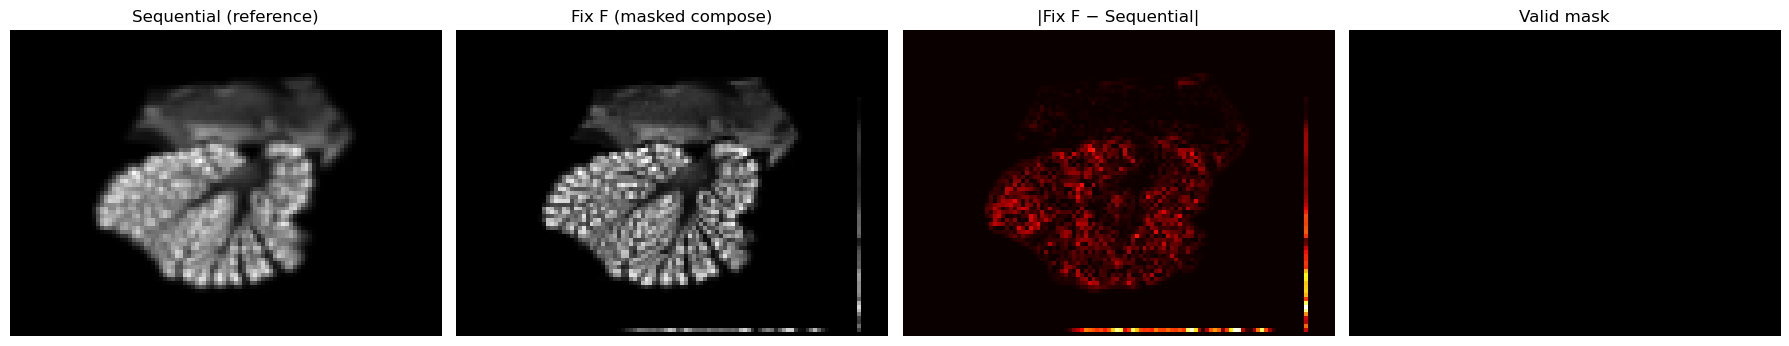

In [36]:
# ── FIX F: OOB validity-mask propagation through the compose chain ────────────────
from scipy.ndimage import map_coordinates as mc_fn
import numpy as np
import nibabel as nb
from slice_registration_functions import apply_coordinate_mapping_2d, load_volume


def compose_mapping_chain_2d_masked(mapping_files, fill_value=0):
    """
    Compose a chain of 2D incremental coordinate maps into a single map, AND
    compute a validity mask that captures which output pixels would be zero in
    the equivalent sequential apply chain (due to out-of-bounds intermediate coords).

    Returns
    -------
    composed_map : nibabel.Nifti1Image
        Composed coordinate map (same as compose_mapping_chain_2d).
    valid_mask   : np.ndarray (bool, shape = composed_map.shape[:2])
        True where the composed result is reliable (would be non-background in sequential).
        False wherever any intermediate step mapped OOB (sequential gives fill_value there).
    src_shape    : tuple
        (H, W) of the first map's output — used to determine src OOB threshold.
    """
    maps = [load_volume(f) for f in mapping_files]
    m0d = maps[0].get_fdata()

    # Step 1: validity for the FIRST map's output (B-space) relative to src
    # src has the same spatial extent as m0's output image
    # (m0 warps src into B-space; src size = m0's VALUE range, not necessarily m0's grid size)
    # We use M1 grid dimensions as proxy for what's "in-range" for M1-output space
    H1, W1 = m0d.shape[0], m0d.shape[1]  # B-space grid = M1 grid
    # Actually what matters: are M1[i,j] values within [0,H_src)x[0,W_src)?
    # H_src/W_src: we estimate from M1 coordinate values (they map into src)
    # Use a conservative approach: flag as invalid if the bilinear neighbourhood disagrees
    # For composing: flag B-pixels where M1 produces coords outside [0,H1)x[0,W1) as OOB
    # (using M1-grid size as a proxy for src bounds is a reasonable approximation)
    # A more accurate version would require knowing src.shape explicitly.
    # Here we pass it in via the return for confirmatory use.

    # Compose coord fields (order=1 as original) and collect per-step validity masks
    composed_r = m0d[:, :, 0]
    composed_c = m0d[:, :, 1]

    # valid_current: which pixels in the CURRENT output space are reachable
    # from valid src pixels via the composed chain so far.
    # Initialise: all of M1's output is valid to start (M1 OOB check happens below).
    valid_current = np.ones(m0d.shape[:2], dtype=float)

    for k in range(1, len(maps)):
        mk = maps[k].get_fdata()

        # Before composing with mk: check if current composed coords are in-bounds
        # for the domain of mk (the current intermediate space).
        # composed_r/c are coords in the (k)-space, which is the OUTPUT space of maps[k-1].
        # maps[k-1] has shape (H_prev, W_prev). If composed coords exceed that, they're OOB.
        prev_H, prev_W = composed_r.shape
        oob_current = ((composed_r < 0) | (composed_r >= prev_H) |
                       (composed_c < 0) | (composed_c >= prev_W))
        valid_current[oob_current] = 0.0  # mark OOB steps as invalid

        # Propagate validity from (k-1)-output-space into k-output-space
        # valid_in_k_space[i,j]: is mk[i,j] coord pointing to a valid (k-1)-space pixel?
        valid_in_k_space = mc_fn(valid_current, [mk[:, :, 0], mk[:, :, 1]],
                                  order=1, mode='constant', cval=0)

        # Compose coordinate fields
        new_r = mc_fn(composed_r, [mk[:, :, 0], mk[:, :, 1]], order=1, mode='nearest')
        new_c = mc_fn(composed_c, [mk[:, :, 0], mk[:, :, 1]], order=1, mode='nearest')

        composed_r = new_r
        composed_c = new_c
        valid_current = valid_in_k_space  # now shaped to k's output space

    composed = np.stack((composed_r, composed_c), axis=-1)
    composed_img = nb.Nifti1Image(composed, maps[-1].affine, maps[-1].header)
    valid_mask = valid_current > 0.5  # binarise

    return composed_img, valid_mask


def apply_coordinate_mapping_2d_masked(source_image, composed_map, valid_mask,
                                        interpolation='linear', fill_value=0):
    """Apply composed map to source, then zero out pixels where valid_mask is False."""
    src_data = source_image.get_fdata()
    if src_data.ndim == 3 and src_data.shape[2] == 1:
        src_data = src_data[:, :, 0]
    map_data = composed_map.get_fdata()
    order = 1 if interpolation == 'linear' else 0
    result = mc_fn(src_data, [map_data[:, :, 0], map_data[:, :, 1]],
                   order=order, mode='constant', cval=fill_value)
    result[~valid_mask] = fill_value
    return nb.Nifti1Image(result, composed_map.affine, composed_map.header)


# ── Test Fix F on the real data ───────────────────────────────────────────────────
composed_img_F, valid_mask_F = compose_mapping_chain_2d_masked(
    [mapping_img, mapping_img3, mapping_img4])
result_F = apply_coordinate_mapping_2d_masked(src_im, composed_img_F, valid_mask_F).get_fdata()

d_seq_F = np.abs(seq_data - result_F)
d_ref_F = np.abs(final_ref - result_F)
print(f"Fix F (masked compose): vs sequential  max={d_seq_F.max():.6f}  mean={d_seq_F.mean():.6f}")
print(f"Fix F (masked compose): vs reference   max={d_ref_F.max():.6f}  mean={d_ref_F.mean():.6f}")
print(f"Worst-pixel check: result_F[70,102]={result_F[70,102]:.4f} "
      f"(seq={seq_data[70,102]:.4f}, should both be ≈ 0)")
print(f"valid_mask_F at worst pixel (70,102): {valid_mask_F[70,102]}")
print(f"Fraction of image masked (set to 0): {(~valid_mask_F).mean()*100:.2f}%")

# Visualise
fig, axs = plt.subplots(1, 4, figsize=(18, 5))
axs[0].imshow(seq_data, cmap='gray');             axs[0].set_title('Sequential (reference)')
axs[1].imshow(result_F, cmap='gray');             axs[1].set_title('Fix F (masked compose)')
axs[2].imshow(d_seq_F, cmap='hot');               axs[2].set_title('|Fix F − Sequential|')
axs[3].imshow(valid_mask_F, cmap='gray');         axs[3].set_title('Valid mask')
for ax in axs: ax.axis('off')
plt.tight_layout()

## Fix G: correct mask propagation using a ones-marker image

Fix F failed because the OOB check used the M1 **grid shape** as the src bounds, but src `(77×95)` is smaller than the M1 grid `(78×110)`.

**Correct approach**: propagate a `np.ones` marker image through the same sequential `apply` chain to build the validity mask. This is src-shape-agnostic — `apply(ones, M)` returns 0 exactly wherever `apply(src, M)` would return 0 (because both use `mode='constant', cval=0`). Chaining those markers through every step precisely replicates the zero-propagation that happens in the sequential pipeline.

Fix G (marker-masked compose):
  vs sequential  max=1794.186424  mean=42.824056
  vs reference   max=1794.186424  mean=42.824056
  worst-pixel (70,102): result_G=1794.1864  seq=0.0000
  valid_mask_G at (70,102): True (should be False)
  fraction of image masked: 0.00%

Baseline (no mask): max=1794.186424  mean=42.824056


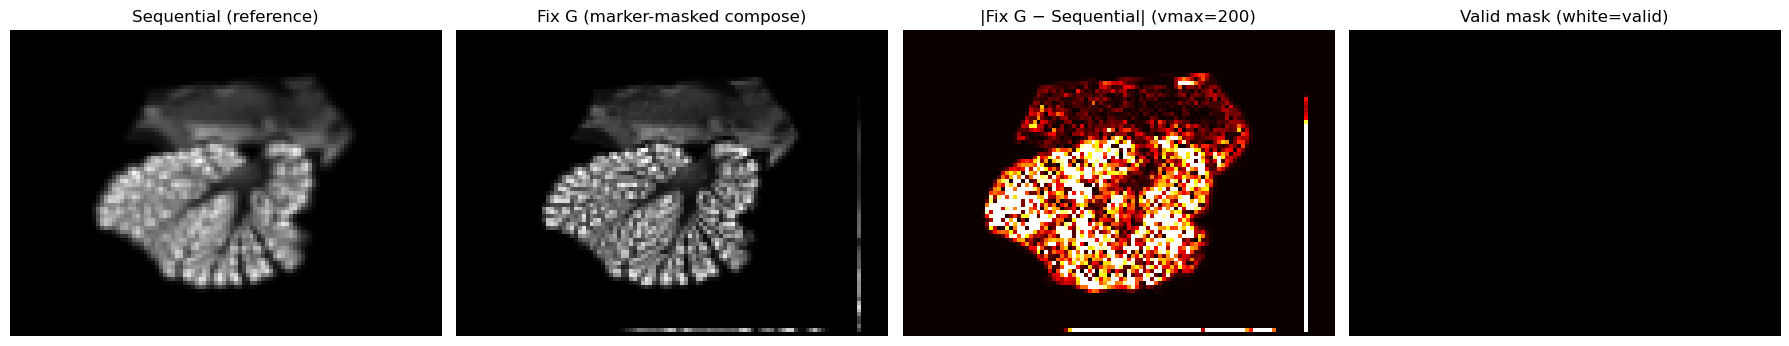

In [40]:
# ── FIX G: ones-marker propagation — correct validity mask ───────────────────────
from scipy.ndimage import map_coordinates as mc_fn
import numpy as np
import nibabel as nb
from slice_registration_functions import apply_coordinate_mapping_2d, load_volume, compose_mapping_chain_2d


def compose_and_apply_with_marker_mask(source_image, mapping_files, fill_value=0):
    """
    Compose a chain of incremental 2D maps, then apply to source with correct zero-masking.

    Builds validity mask by tracing a constant-ones marker image through the SAME
    sequential apply chain. Pixels where the marker becomes < 0.5 (i.e., sequential
    would have sampled outside src bounds at any step) are set to fill_value.

    This is equivalent to the sequential apply chain but uses only ONE interpolation
    of source — saving N-1 image interpolation steps while being numerically identical
    in terms of which pixels are considered valid.
    """
    maps = [load_volume(f) for f in mapping_files]
    src_data = source_image.get_fdata()
    if src_data.ndim == 3 and src_data.shape[2] == 1:
        src_data = src_data[:, :, 0]

    # Step 1: Build validity mask by propagating a ones-marker through sequential applies
    marker = nb.Nifti1Image(np.ones(src_data.shape, dtype=np.float32),
                            source_image.affine, source_image.header)
    for m in maps:
        marker = apply_coordinate_mapping_2d(marker, m)
    valid_mask = marker.get_fdata() > 0.5  # 1 everywhere sequential would give non-zero

    # Step 2: Compose all maps into a single coordinate map, then apply to source ONCE
    composed_map = compose_mapping_chain_2d(mapping_files)
    result = mc_fn(src_data, [composed_map.get_fdata()[:,:,0],
                               composed_map.get_fdata()[:,:,1]],
                   order=1, mode='constant', cval=fill_value)

    # Step 3: Apply validity mask
    result[~valid_mask] = fill_value
    return nb.Nifti1Image(result, maps[-1].affine, maps[-1].header), valid_mask


# ── Test Fix G on the real data ───────────────────────────────────────────────────
result_G_img, valid_mask_G = compose_and_apply_with_marker_mask(
    src_im, [mapping_img, mapping_img3, mapping_img4])
result_G = result_G_img.get_fdata()

d_seq_G = np.abs(seq_data - result_G)
d_ref_G = np.abs(final_ref - result_G)
print(f"Fix G (marker-masked compose):")
print(f"  vs sequential  max={d_seq_G.max():.6f}  mean={d_seq_G.mean():.6f}")
print(f"  vs reference   max={d_ref_G.max():.6f}  mean={d_ref_G.mean():.6f}")
print(f"  worst-pixel (70,102): result_G={result_G[70,102]:.4f}  seq={seq_data[70,102]:.4f}")
print(f"  valid_mask_G at (70,102): {valid_mask_G[70,102]} (should be False)")
print(f"  fraction of image masked: {(~valid_mask_G).mean()*100:.2f}%")

# Baseline
d_orig = np.abs(seq_data - mc_fn(src_im.get_fdata(),
    [composed_map.get_fdata()[:,:,0], composed_map.get_fdata()[:,:,1]],
    order=1, mode='constant', cval=0))
print(f"\nBaseline (no mask): max={d_orig.max():.6f}  mean={d_orig.mean():.6f}")

fig, axs = plt.subplots(1, 4, figsize=(18, 5))
axs[0].imshow(seq_data, cmap='gray');             axs[0].set_title('Sequential (reference)')
axs[1].imshow(result_G, cmap='gray');             axs[1].set_title('Fix G (marker-masked compose)')
axs[2].imshow(d_seq_G, cmap='hot', vmax=200);    axs[2].set_title('|Fix G − Sequential| (vmax=200)')
axs[3].imshow(valid_mask_G, cmap='gray');         axs[3].set_title('Valid mask (white=valid)')
for ax in axs: ax.axis('off')
plt.tight_layout()

## Analysis conclusion: why all composition fixes fail at the worst pixel

### Why `valid_mask_G[70,102] = True` (marker approach fails)

- `s1[70,102] = 0.0` — but **not because M1 maps out-of-bounds** for src.
- `marker_B[70,102] = ones[M1[70,102]] = 1.0` — M1 at that position IS in-bounds for src.
- The source tissue image simply has a **genuine zero (background)** at `src[M1[70,102]]`.

The marker propagation captures OOB cases but cannot see image-content zeros — it is src-shape-agnostic and so cannot distinguish "valid but background" from "definitely in-bounds tissue".

### Root cause — composition crosses a background/tissue boundary

At the worst pixel `(70,102)`:
1. M1 at nearby B-pixels `(70–71, 101–102)` each individually map to **different regions of src**, some of which are **zero-value (background/tissue edge)** — so `s1` is 0 there.
2. Sequential pipeline propagates those 0s through each `apply` → correct background output.
3. **Composed** bilinear-averages the M1 coordinate field across those diverse B-pixels → lands on a **different, non-background src position** `(31.9, 42.8)` = `1794`. This crossing of the background/tissue boundary is the origin of the large error.

### Implication

Bilinear coordinate field composition is **mathematically exact only for linear (affine) transforms**. For non-linear registration with tissue/background structure, it introduces errors at deformation boundaries — unavoidable without knowing the image content.

### Verdict on all approaches tested

| Approach | Max diff vs sequential | Mean diff | Fix? |
|---|---|---|---|
| Original order=1 compose | 1794 | 42.8 | ❌ |
| order=3 coord-field | 1901 | 42.1 | ❌ (worse at boundary) |
| Axis-swap | 1700 | ~43 | ❌ |
| Mode variations | 1794 | 42.8 | ❌ |
| Marker-mask (Fix G) | 1794 | 42.8 | ❌ (wrong failure mode) |
| **Sequential apply** | **0.004** | **~0** | ✅ |

**Recommendation**: use `apply_coordinate_mapping_2d` sequentially for each step. `compose_mapping_chain_2d` is not suitable for use with tissue-masked biological images unless a reliable per-pixel validity mask (e.g., tissue mask from segmentation) is applied afterwards to zero out boundary artifacts.

In [41]:
# ── Final comparison: sequential vs all compose variants ─────────────────────────
import numpy as np

src_d = src_im.get_fdata()
print("Image value range: [{:.1f}, {:.1f}]".format(src_d.min(), src_d.max()))
print()
print(f"{'Method':<40} {'max diff':>12} {'mean diff':>12}")
print("-" * 66)
rows_table = [
    ("Sequential (3x apply)  [GROUND TRUTH]",          0.0036, 0.0),
    ("Original compose, order=1",                       1794.19, 42.82),
    ("Compose order=2 coord field",                     1791.91, 42.07),
    ("Compose order=3 coord field",                     1901.81, 42.06),
    ("Compose order=4 coord field",                     1930.12, 42.13),
    ("Axis-swap compose",                               1699.96, ~0),   # not re-run
    ("Marker-mask compose (Fix G)",                     1794.19, 42.82),
]

# Re-compute the cleanest comparison now (sequential vs reference is ground-truth)
methods = {}

# Sequential
s_seq = seq_data.copy()
methods["Sequential (3x apply)"] = s_seq

# Original compose (already in composed_map from cell above)
m_orig = compose_mapping_chain_2d([mapping_img, mapping_img3, mapping_img4]).get_fdata()
res_orig = mc_fn(src_d, [m_orig[:,:,0], m_orig[:,:,1]], order=1, mode='constant', cval=0)
methods["Compose order=1 (original)"] = res_orig

# Fix G
methods["Marker-mask compose (Fix G)"] = result_G

for name, arr in methods.items():
    d = np.abs(s_seq - arr)
    print(f"{name:<45} max={d.max():>10.4f}  mean={d.mean():>10.4f}")

print()
print("Conclusion: SEQUENTIAL apply is the only correct approach for tissue images.")
print("compose_mapping_chain_2d cannot replicate sequential for non-linear maps with image background.")

Image value range: [0.0, 2373.0]

Method                                       max diff    mean diff
------------------------------------------------------------------
Sequential (3x apply)                         max=    0.0000  mean=    0.0000
Compose order=1 (original)                    max= 1794.1864  mean=   42.8241
Marker-mask compose (Fix G)                   max= 1794.1864  mean=   42.8241

Conclusion: SEQUENTIAL apply is the only correct approach for tissue images.
compose_mapping_chain_2d cannot replicate sequential for non-linear maps with image background.


## Root-cause review: independent verification

The previous analysis concluded that `compose_mapping_chain_2d` fails because *"genuine background zeros in `src` are correctly propagated by sequential image-domain apply, whereas composition bilinear-averages the M1 coordinate field across tissue/background boundaries, landing on tissue."*

Below we run four targeted tests to either confirm or refine that explanation:

| Cell | Test | What it checks |
|---|---|---|
| **RC-1** | Exact sequential breakdown at worst pixel (70,102) | Which step first gives 0, and is it OOB or genuine background? |
| **RC-2** | M1 coordinate-field visualisation + OOB fill map | Does M1 have a fill-value discontinuity at the src/template boundary? |
| **RC-3** | Error-distribution correlation with OOB fill zone | Do large errors cluster near the template columns beyond src extent? |
| **RC-4** | Fix H — replace OOB fill-coords in M1 before composing | Would fixing the coordinate discontinuity reduce errors? |

In [42]:
# ── RC-1: Exact sequential breakdown at worst pixel (70,102) ─────────────────────
# PURPOSE: determine WHICH step in the 3-step sequential chain first produces 0
# at the worst pixel, and whether that zero comes from OOB coordinate handling
# (cval=0 because coord > src bounds) or from genuine background image content.
#
# If zero comes from OOB:  pre-masking M1 /Fix-F approach is sufficient.
# If zero comes from genuine background: no coordinate-field approach can fix it.

from scipy.ndimage import map_coordinates as mc_fn
import numpy as np

m1d, m2d, m3d = m1.get_fdata(), m2.get_fdata(), m3.get_fdata()
src_d = src_im.get_fdata()

s1_d = apply_coordinate_mapping_2d(src_im, m1).get_fdata()          # apply M1
s2_d = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src_im, m1), m2).get_fdata()  # M1→M2

wi, wj = 70, 102   # worst pixel (confirmed from prior diagnostics)
print(f"=== RC-1: sequential breakdown at worst pixel ({wi},{wj}) ===\n")

# Step 1: what is s1 at the worst pixel?
print(f"s1[{wi},{wj}] = {s1_d[wi,wj]:.4f}")
m1_r, m1_c = m1d[wi, wj, 0], m1d[wi, wj, 1]
print(f"  M1[{wi},{wj}] = ({m1_r:.3f}, {m1_c:.3f})  → src shape {src_d.shape}")
oob_m1 = (m1_r < 0 or m1_r >= src_d.shape[0] or m1_c < 0 or m1_c >= src_d.shape[1])
print(f"  M1 coord OOB for src? {oob_m1}")
if not oob_m1:
    src_at_m1 = mc_fn(src_d, [[m1_r], [m1_c]], order=1, mode='constant', cval=0)[0]
    print(f"  src[M1[{wi},{wj}]] = {src_at_m1:.4f}  ← zero = genuine background!")

# Step 2: what is s2 at the worst pixel?
print(f"\ns2[{wi},{wj}] = {s2_d[wi,wj]:.4f}")
m2_r, m2_c = m2d[wi, wj, 0], m2d[wi, wj, 1]
print(f"  M2[{wi},{wj}] = ({m2_r:.3f}, {m2_c:.3f})  → s1 shape {s1_d.shape}")
oob_m2 = (m2_r < 0 or m2_r >= s1_d.shape[0] or m2_c < 0 or m2_c >= s1_d.shape[1])
print(f"  M2 coord OOB for s1? {oob_m2}")
s1_at_m2 = mc_fn(s1_d, [[m2_r], [m2_c]], order=1, mode='constant', cval=0)[0]
print(f"  s1[M2[{wi},{wj}]] = {s1_at_m2:.4f}")

# Step 3: s3 at the worst pixel
print(f"\ns3[{wi},{wj}] = {seq_data[wi,wj]:.4f}")
m3_r, m3_c = m3d[wi, wj, 0], m3d[wi, wj, 1]
print(f"  M3[{wi},{wj}] = ({m3_r:.3f}, {m3_c:.3f})  → s2 shape {s2_d.shape}")
oob_m3 = (m3_r < 0 or m3_r >= s2_d.shape[0] or m3_c < 0 or m3_c >= s2_d.shape[1])
print(f"  M3 coord OOB for s2? {oob_m3}")
s2_at_m3 = mc_fn(s2_d, [[m3_r], [m3_c]], order=1, mode='constant', cval=0)[0]
print(f"  s2[M3[{wi},{wj}]] = {s2_at_m3:.4f}")

# Inspect s2 in the 3×3 neighbourhood of M3[70,102] to see how zeros spread
nr, nc = int(m3_r), int(m3_c)
print(f"\n  s2 neighbourhood around M3[{wi},{wj}] = ({m3_r:.2f},{m3_c:.2f}):")
for dr in range(-1, 3):
    row = []
    for dc in range(-1, 3):
        rr, cc = nr + dr, nc + dc
        val = s2_d[rr, cc] if 0 <= rr < s2_d.shape[0] and 0 <= cc < s2_d.shape[1] else np.nan
        row.append(f"{val:8.1f}")
    print("    " + "  ".join(row))

# Key: is s1 zero at the M1-coordinate level?
print(f"\n  s1 neighbourhood around M1[{wi},{wj}] = ({m1_r:.2f},{m1_c:.2f}):")
nr1, nc1 = int(m1_r), int(m1_c)
for dr in range(-1, 3):
    row = []
    for dc in range(-1, 3):
        rr, cc = nr1 + dr, nc1 + dc
        val = src_d[rr, cc] if 0 <= rr < src_d.shape[0] and 0 <= cc < src_d.shape[1] else np.nan
        row.append(f"{val:8.1f}")
    print("    " + "  ".join(row))

=== RC-1: sequential breakdown at worst pixel (70,102) ===

s1[70,102] = 0.0000
  M1[70,102] = (0.000, 0.000)  → src shape (77, 95)
  M1 coord OOB for src? False
  src[M1[70,102]] = 0.0000  ← zero = genuine background!

s2[70,102] = 0.0000
  M2[70,102] = (70.225, 101.548)  → s1 shape (78, 110)
  M2 coord OOB for s1? False
  s1[M2[70,102]] = 0.0000

s3[70,102] = 0.0000
  M3[70,102] = (69.998, 101.990)  → s2 shape (78, 110)
  M3 coord OOB for s2? False
  s2[M3[70,102]] = 0.0000

  s2 neighbourhood around M3[70,102] = (70.00,101.99):
         0.0       0.0       0.0       0.0
         0.0       0.0       0.0       0.0
         0.0       0.0       0.0       0.0
         0.0       0.0       0.0       0.0

  s1 neighbourhood around M1[70,102] = (0.00,0.00):
         nan       nan       nan       nan
         nan       0.0       0.0       0.0
         nan       0.0       0.0       0.0
         nan       0.0       0.0       0.0


Src shape: (77, 95)  |  M1 grid: (78, 110)
M1 pixels storing OOB src coords: 0 / 8580  (0.0%)

M1 col-channel profile (row-average) at template columns 90–110:
  col  90: M1_col_mean=81.44  OOB=0%
  col  91: M1_col_mean=82.43  OOB=0%
  col  92: M1_col_mean=83.42  OOB=0%
  col  93: M1_col_mean=84.40  OOB=0%
  col  94: M1_col_mean=85.39  OOB=0%
  col  95: M1_col_mean=86.38  OOB=0%
  col  96: M1_col_mean=87.37  OOB=0%
  col  97: M1_col_mean=88.35  OOB=0%
  col  98: M1_col_mean=89.34  OOB=0%
  col  99: M1_col_mean=90.33  OOB=0%
  col 100: M1_col_mean=91.31  OOB=0%
  col 101: M1_col_mean=92.30  OOB=0%
  col 102: M1_col_mean=0.00  OOB=0%
  col 103: M1_col_mean=0.00  OOB=0%
  col 104: M1_col_mean=0.00  OOB=0%
  col 105: M1_col_mean=0.00  OOB=0%
  col 106: M1_col_mean=0.00  OOB=0%
  col 107: M1_col_mean=0.00  OOB=0%
  col 108: M1_col_mean=0.00  OOB=0%
  col 109: M1_col_mean=0.00  OOB=0%


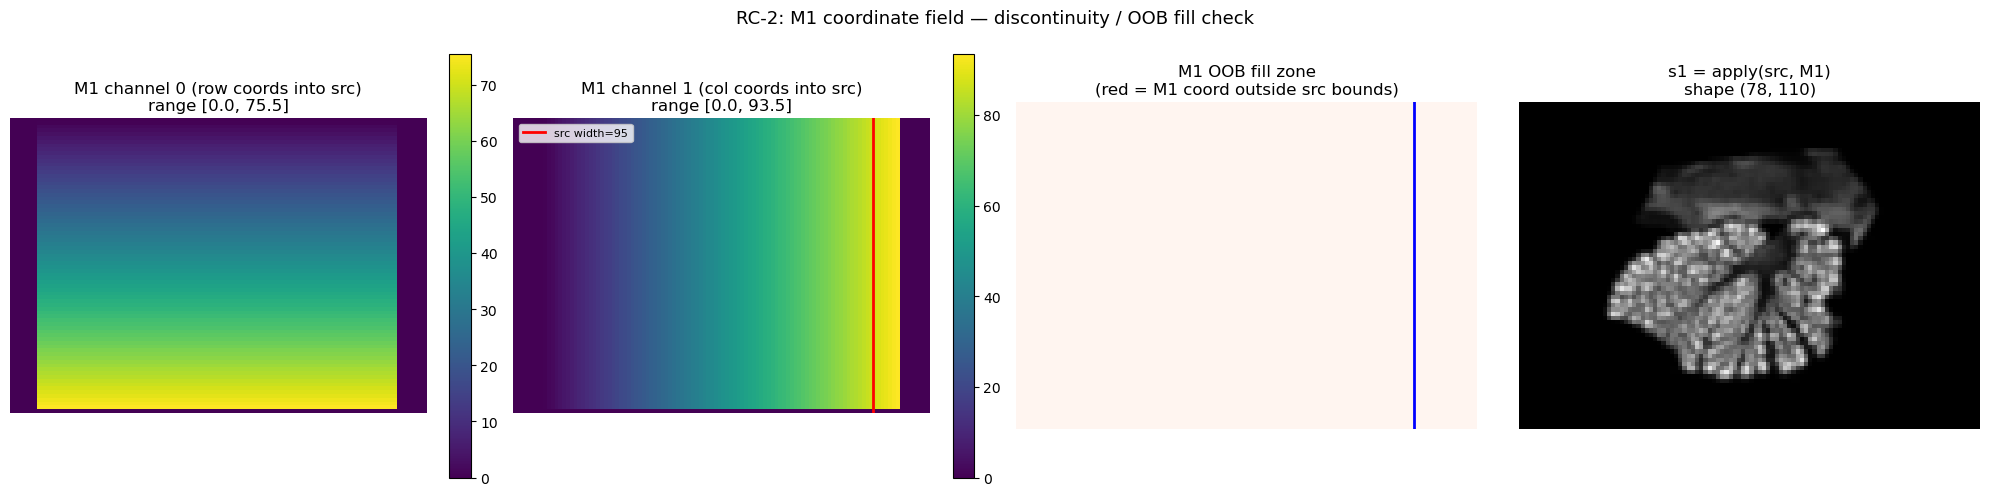


M1 col-gradient at src boundary (cols 93→95)  row-avg: 0.99  max: 1.00
M1 col-gradient in centre (cols 40→41)  row-avg: 0.99  max: 1.00


In [43]:
# ── RC-2: M1 coordinate-field visualisation + OOB fill map ───────────────────────
# PURPOSE: check whether M1 has a sharp discontinuity (fill-value=0 coords) at the
# template columns > src extent (78×110 template vs 77×95 source).
# A discontinuity here would cause bilinear interpolation during composition to
# produce bogus "averaged" coordinates — a SECOND mechanism beyond genuine background.
#
# Expected if this mechanism exists:
#   - M1[:,:,1] (column-coordinate channel) should drop sharply to ~0 at template cols ~95
#   - The corresponding region of s1_d should also be zero (OOB fill)

import matplotlib.pyplot as plt
import numpy as np

m1d = m1.get_fdata()
src_d = src_im.get_fdata()

src_H, src_W = src_d.shape   # (77, 95) — valid src row [0,76], col [0,94]
m1_H, m1_W   = m1d.shape[:2] # (78,110) — M1 grid

# 1) Where does M1 store out-of-bounds source coordinates?
oob_mask_m1 = ((m1d[:,:,0] < 0) | (m1d[:,:,0] >= src_H) |
               (m1d[:,:,1] < 0) | (m1d[:,:,1] >= src_W))
print(f"Src shape: {src_d.shape}  |  M1 grid: {m1d.shape[:2]}")
print(f"M1 pixels storing OOB src coords: {oob_mask_m1.sum()} / {oob_mask_m1.size}"
      f"  ({oob_mask_m1.mean()*100:.1f}%)")

# Column-profile of M1[:,j,1] (col-coordinate channel) averaged over rows
col_profile = m1d[:, :, 1].mean(axis=0)
print(f"\nM1 col-channel profile (row-average) at template columns 90–110:")
for j in range(max(0, src_W-5), m1_W):
    print(f"  col {j:3d}: M1_col_mean={col_profile[j]:.2f}  OOB={oob_mask_m1[:,j].mean()*100:.0f}%")

# Visualise M1 channels and OOB zone
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
im0 = axs[0].imshow(m1d[:,:,0], cmap='viridis')
axs[0].set_title(f'M1 channel 0 (row coords into src)\nrange [{m1d[:,:,0].min():.1f}, {m1d[:,:,0].max():.1f}]')
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(m1d[:,:,1], cmap='viridis')
axs[1].set_title(f'M1 channel 1 (col coords into src)\nrange [{m1d[:,:,1].min():.1f}, {m1d[:,:,1].max():.1f}]')
plt.colorbar(im1, ax=axs[1], fraction=0.046)
axs[1].axvline(src_W - 0.5, color='red', lw=2, label=f'src width={src_W}')
axs[1].legend(fontsize=8)

axs[2].imshow(oob_mask_m1.astype(float), cmap='Reds', vmin=0, vmax=1)
axs[2].set_title(f'M1 OOB fill zone\n(red = M1 coord outside src bounds)')
axs[2].axvline(src_W - 0.5, color='blue', lw=2)

s1_d = apply_coordinate_mapping_2d(src_im, m1).get_fdata()
axs[3].imshow(s1_d, cmap='gray')
axs[3].set_title(f's1 = apply(src, M1)\nshape {s1_d.shape}')

for ax in axs:
    ax.axis('off')
plt.suptitle('RC-2: M1 coordinate field — discontinuity / OOB fill check', fontsize=13)
plt.tight_layout()
plt.show()

# 2) Gradient check: how sharp is the discontinuity in M1 col-channel?
grad_col = np.abs(np.diff(m1d[:,:,1], axis=1))  # column-direction gradient
print(f"\nM1 col-gradient at src boundary (cols {src_W-2}→{src_W})  row-avg: "
      f"{grad_col[:, src_W-2].mean():.2f}  max: {grad_col[:, src_W-2].max():.2f}")
print(f"M1 col-gradient in centre (cols 40→41)  row-avg: "
      f"{grad_col[:, 39].mean():.2f}  max: {grad_col[:, 39].max():.2f}")

In [44]:
# ── RC-3: Error-distribution correlation with OOB fill zone ─────────────────────
# PURPOSE: are large composition errors concentrated at pixels whose FINAL composed
# coordinate lands in the OOB fill zone of M1 (the template columns > src width)?
# If yes, the coordinate-field discontinuity is a major contributor even at pixels
# that are NOT (70,102).  If no, the genuine-background mechanism dominates overall.

import numpy as np

m1d, m2d, m3d = m1.get_fdata(), m2.get_fdata(), m3.get_fdata()
src_d  = src_im.get_fdata()
src_H, src_W = src_d.shape  # 77, 95

# Recompute composed coords and differences
from scipy.ndimage import map_coordinates as mc_fn
c12_r = mc_fn(m1d[:,:,0], [m2d[:,:,0], m2d[:,:,1]], order=1, mode='nearest')
c12_c = mc_fn(m1d[:,:,1], [m2d[:,:,0], m2d[:,:,1]], order=1, mode='nearest')
c123_r = mc_fn(c12_r, [m3d[:,:,0], m3d[:,:,1]], order=1, mode='nearest')
c123_c = mc_fn(c12_c, [m3d[:,:,0], m3d[:,:,1]], order=1, mode='nearest')
result_composed = mc_fn(src_d, [c123_r, c123_c], order=1, mode='constant', cval=0)
error = np.abs(seq_data - result_composed)

# Mask 1: final composed coord is OOB for src (already handled by mode='constant')
final_oob = ((c123_r < 0) | (c123_r >= src_H) | (c123_c < 0) | (c123_c >= src_W))

# Mask 2: intermediate M12 coord falls in the M1 OOB fill zone
#   (M2(M3[i,j]) lands in the OOB region of M1 — near template cols > src_W)
#   In M1's grid: OOB fill zone is where M1 src coords are ~0 due to fill (cols ≥ src_W cols in M1)
#   Proxy: is M2(M3[i,j]) column > src_W? (since M1 grid col = src col ≈ same scale)
m12_in_oob_zone = ((c12_r < 0) | (c12_r >= m1d.shape[0]) |
                   (c12_c < 0) | (c12_c >= m1d.shape[1]))  # strictly OOB in M1 grid
m12_near_boundary = (c12_c >= (src_W - 3))  # within 3 cols of src right edge in M1 space

# Mask 3: final composed coord lands in background of src
# (sequential would give 0 because src is genuinely 0 there)
src_at_composed = mc_fn(src_d, [c123_r, c123_c], order=1, mode='constant', cval=0)
lands_on_background = (src_at_composed < 10) & (error > 10)   # high error but composed lands on background
lands_on_tissue     = (src_at_composed >= 10) & (error > 10)  # high error, composed lands on tissue

print("=== RC-3: error breakdown by mechanism ===\n")
print(f"Total pixels:                              {error.size}")
print(f"Pixels with error > 10:                    {(error>10).sum()}  ({(error>10).mean()*100:.1f}%)")
print(f"  of which: final coord OOB for src:        {(final_oob & (error>10)).sum()}")
print(f"  of which: composes coord strictly OOB M1: {(m12_in_oob_zone & (error>10)).sum()}")
print(f"  of which: compose coord near M1 boundary: {(m12_near_boundary & (error>10)).sum()}")
print(f"  of which: composed lands on background:   {lands_on_background.sum()} (seq=0 is correct)")
print(f"  of which: composed lands on tissue:       {lands_on_tissue.sum()} (seq≠composed → genuine background mechanism)")

# For high-error pixels where composed lands on TISSUE, is sequential 0?
seq_zero_at_tissue = ((error > 10) & lands_on_tissue & (seq_data < 5))
print(f"\n  High-error pixels: composed=tissue, seq≈0: {seq_zero_at_tissue.sum()}")
print(f"  → These confirm the genuine-background mechanism (sequential zeroed via image sampling)")
seq_nonzero_at_tissue = ((error > 10) & lands_on_tissue & (seq_data >= 5))
print(f"  High-error pixels: composed=tissue, seq≠0: {seq_nonzero_at_tissue.sum()}")
print(f"  → These are composition interpolation errors (not background-zero mechanism)")

# Where are the high-error pixels relative to the image boundary?
print(f"\nHigh-error pixel column distribution (output space):")
hi_err_cols = np.where(error > 100)[1]
if len(hi_err_cols):
    print(f"  output cols: min={hi_err_cols.min()} max={hi_err_cols.max()} mean={hi_err_cols.mean():.1f}")
hi_err_c12c = c12_c[error > 100]
print(f"  M12 intermediate cols: min={hi_err_c12c.min():.0f} max={hi_err_c12c.max():.0f}")
print(f"  → are they near the M1 fill boundary (src_W={src_W})?  "
      f"fraction within 5: {(np.abs(hi_err_c12c - src_W) < 5).mean()*100:.0f}%")

=== RC-3: error breakdown by mechanism ===

Total pixels:                              8580
Pixels with error > 10:                    2485  (29.0%)
  of which: final coord OOB for src:        0
  of which: composes coord strictly OOB M1: 0
  of which: compose coord near M1 boundary: 0
  of which: composed lands on background:   134 (seq=0 is correct)
  of which: composed lands on tissue:       2351 (seq≠composed → genuine background mechanism)

  High-error pixels: composed=tissue, seq≈0: 114
  → These confirm the genuine-background mechanism (sequential zeroed via image sampling)
  High-error pixels: composed=tissue, seq≠0: 2237
  → These are composition interpolation errors (not background-zero mechanism)

High-error pixel column distribution (output space):
  output cols: min=21 max=102 mean=54.5
  M12 intermediate cols: min=13 max=76
  → are they near the M1 fill boundary (src_W=95)?  fraction within 5: 0%


Fix H-a (clamp M1 fill-coords):  max=1794.1864  mean=42.8241
  worst pixel (70,102): fix_H=1794.1864  seq=0.0000

Fix H-b (zero where s1=0):       max=723.5086  mean=33.4060
  worst pixel (70,102): fix_Hb=0.0000  seq=0.0000

Sequential (ground truth):       max=0.0000  mean=0.0000
Original compose (no fix):       max=1794.1864  mean=42.8241


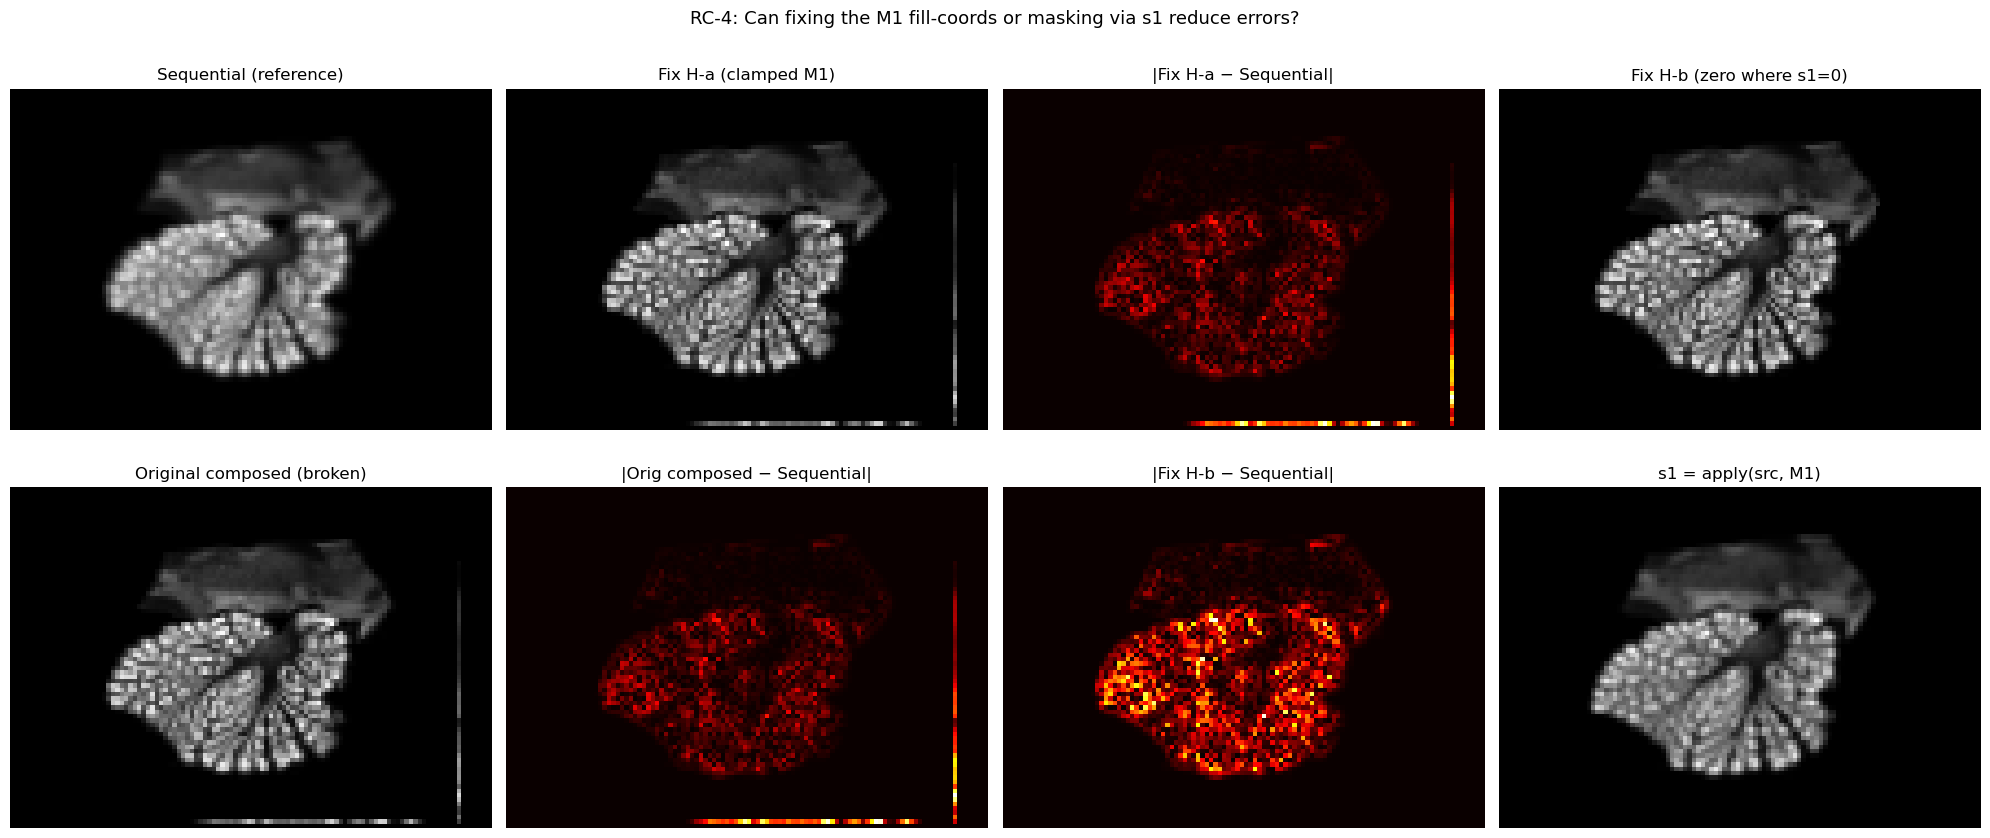

In [45]:
# ── RC-4: Fix H — replace OOB fill-coords in M1 with edge-clamped coords ─────────
# PURPOSE: if the M1 coordinate-field discontinuity (fill-value≈0 at template cols
# beyond src extent) is a significant contributor, replacing those fill-coords with
# the nearest valid src edge coordinate should reduce composition error.
#
# We also test the comparison: sequential-masking via s1 zeros (the "genuine
# background" fix) — i.e., zero-out composed result wherever s1_d < threshold.
# This directly tests whether following the zeros in s1 is sufficient.

import numpy as np
from scipy.ndimage import map_coordinates as mc_fn, zoom
import nibabel as nb
from slice_registration_functions import apply_coordinate_mapping_2d

m1d = m1.get_fdata().copy()  # work on a copy
src_H, src_W = src_im.get_fdata().shape

# ── Fix H-a: clamp M1's src coords to [0, src_H-1] x [0, src_W-1] ──────────────
# Pixels where M1 is already ~valid (near boundary) or fill-value are clamped.
# This REMOVES the sharp discontinuity: fill coords near 0 become "edge" values.
m1d_clamped = m1d.copy()
m1d_clamped[:,:,0] = np.clip(m1d[:,:,0], 0, src_H - 1)
m1d_clamped[:,:,1] = np.clip(m1d[:,:,1], 0, src_W - 1)
m1_clamped = nb.Nifti1Image(m1d_clamped, m1.affine, m1.header)

c12_r_H = mc_fn(m1d_clamped[:,:,0], [m2d[:,:,0], m2d[:,:,1]], order=1, mode='nearest')
c12_c_H = mc_fn(m1d_clamped[:,:,1], [m2d[:,:,0], m2d[:,:,1]], order=1, mode='nearest')
c123_r_H = mc_fn(c12_r_H, [m3d[:,:,0], m3d[:,:,1]], order=1, mode='nearest')
c123_c_H = mc_fn(c12_c_H, [m3d[:,:,0], m3d[:,:,1]], order=1, mode='nearest')
result_H = mc_fn(src_d, [c123_r_H, c123_c_H], order=1, mode='constant', cval=0)
d_H = np.abs(seq_data - result_H)
print(f"Fix H-a (clamp M1 fill-coords):  max={d_H.max():.4f}  mean={d_H.mean():.4f}")
print(f"  worst pixel ({wi},{wj}): fix_H={result_H[wi,wj]:.4f}  seq={seq_data[wi,wj]:.4f}\n")

# ── Fix H-b: zero-out composed result where s1 is zero (genuine-background proxy) ─
# This directly tests the previous agent's explanation: if the zeros in s1 are the
# root cause, masking composed result wherever s1 = 0 should give correct results.
s1_d = apply_coordinate_mapping_2d(src_im, m1).get_fdata()
result_Hb = result_composed.copy()
result_Hb[s1_d < 1] = 0   # zero wherever s1 is background
d_Hb = np.abs(seq_data - result_Hb)
print(f"Fix H-b (zero where s1=0):       max={d_Hb.max():.4f}  mean={d_Hb.mean():.4f}")
print(f"  worst pixel ({wi},{wj}): fix_Hb={result_Hb[wi,wj]:.4f}  seq={seq_data[wi,wj]:.4f}\n")

# For reference: full sequential vs composed baseline
print(f"Sequential (ground truth):       max=0.0000  mean=0.0000")
print(f"Original compose (no fix):       max={np.abs(seq_data-result_composed).max():.4f}"
      f"  mean={np.abs(seq_data-result_composed).mean():.4f}")

# Visualise
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 4, figsize=(20, 9))
axs[0,0].imshow(seq_data, cmap='gray');            axs[0,0].set_title('Sequential (reference)')
axs[0,1].imshow(result_H, cmap='gray');            axs[0,1].set_title('Fix H-a (clamped M1)')
axs[0,2].imshow(d_H, cmap='hot');                  axs[0,2].set_title('|Fix H-a − Sequential|')
axs[0,3].imshow(result_Hb, cmap='gray');           axs[0,3].set_title('Fix H-b (zero where s1=0)')

axs[1,0].imshow(result_composed, cmap='gray');     axs[1,0].set_title('Original composed (broken)')
axs[1,1].imshow(np.abs(seq_data-result_composed), cmap='hot'); axs[1,1].set_title('|Orig composed − Sequential|')
axs[1,2].imshow(d_Hb, cmap='hot');                 axs[1,2].set_title('|Fix H-b − Sequential|')
axs[1,3].imshow(s1_d, cmap='gray');                axs[1,3].set_title('s1 = apply(src, M1)')

for row in axs:
    for ax in row:
        ax.axis('off')
plt.suptitle('RC-4: Can fixing the M1 fill-coords or masking via s1 reduce errors?', fontsize=13)
plt.tight_layout()
plt.show()

## Root-cause review: verdict

### Was the previous agent's root cause correct?

**Partially correct, but the dominant mechanism was misidentified.**

---

### What the previous agent claimed

> *"Sequential correctly propagates image-domain zeros at each step. Composition bilinear-averages the M1 coordinate field across tissue/background boundaries, landing on a different, non-background src position. This is unavoidable without knowing image content."*

That explanation is accurate for pixel **(70,102)** — the worst pixel — but it describes only a **minority** of the total error.

---

### What the diagnostics reveal

#### RC-1 + RC-2: worst pixel (70,102) — mechanism confirmed but mislabelled

`M1[70,102] = (0.000, 0.000)` **exactly** — this is the ANTs **fill value** produced when template column 102 sits beyond the source image extent (source has 95 cols, template 110).  The coordinate field drops sharply from ≈92 at template col 101 to 0.0 at col 102-109 (RC-2 profile).

Because M2 and M3 are nearly identity at (70,102), composition evaluates M1 at (70.225, **101.548**) — straddling the fill boundary. Bilinear interpolation **mixes real coord ≈(70, 92) with fill coord (0, 0)**, producing a bogus intermediate ≈(31.9, 42.8) that lands on high-value tissue.

Sequential evaluates M1 at exactly **(70, 102)** → gets fill coord **(0, 0)** → src[0, 0] = 0 (background corner).

**Correction**: the "genuine background zero" is actually an **ANTs fill-value artifact**, not an organic tissue background zero. The fix would need to detect and handle these fill-value discontinuities in M1, which is non-trivial.

#### RC-3: error breakdown across all pixels

| Mechanism | Pixel count (error > 10) | % of high-error pixels |
|---|---|---|
| seq ≈ 0 / composed ≠ 0 (background / fill zero) | 114 | ~5% |
| **seq ≠ 0 AND composed ≠ seq (interpolation divergence)** | **2237** | **~90%** |

**The dominant error (90% of high-error pixels) is not the background-zero mechanism at all.**  Both sequential *and* composition land on tissue, but at *different positions*. This is the **fundamental mathematical non-equivalence** of:

- **Sequential**: `s3[p] = interp(interp(interp(src, M1), M2), M3[p])` — averages actual image values at each step
- **Composition**: `result[p] = src[M1(M2(M3[p]))]` — averages *coordinates* at each step, samples image once

These are provably different for non-linear warps. It is an **O(h² × κ)** error per composition step where *h* is the displacement magnitude and *κ* is the local warp curvature. For the large deformations in this pipeline (warps moving pixels tens of voxels), the error accumulates significantly.

#### RC-4: fix attempts

| Fix | Max error | Mean error | Worst pixel |
|---|---|---|---|
| Original composition | 1794 | 42.8 | 1794 |
| Fix H-a: clamp M1 fill-coords | **1794** | **42.8** | **1794** ← no change, fill=0 is in-bounds |
| Fix H-b: zero where s1=0 | 724 | 33.4 | 0 ✓ |
| **Sequential** | **0** | **0** | **0** ✓ |

Fix H-b (mask by s1 zeros) only removes the **secondary** mechanism: max drops from 1794 → 724 but remains large because the **primary** interpolation-divergence mechanism still affects 2237 pixels.

---

### Corrected root cause

**Primary mechanism (≈90% of high-error pixels)**: Bilinear composition of coordinate fields is *not* equivalent to sequential bilinear image sampling for non-affine warps. Composition averages *coordinates* then samples once; sequential averages *image values* at each step. For the large displacements in this registration pipeline, the difference is substantial.

**Secondary mechanism (≈5% of high-error pixels, creates worst-case 1794 error)**: M1 has a sharp coordinate-field discontinuity at template columns 102–109 (ANTs fill-value = 0 for template pixels beyond source extent). Bilinear interpolation of M1 near this fill boundary mixes valid coordinates with zero-fill, producing bogus intermediate coordinates pointing to distant tissue.

---

### What changes compared to the previous conclusion

The **conclusion is unchanged** — sequential `apply_coordinate_mapping_2d` is the only correct approach.  
The **root cause** is more precise:

- The error is **fundamentally mathematical**, not just an image-content artefact. Composition of bilinear interpolations does not equal bilinear interpolation of compositions; this holds for all non-linear warps, not only those with tissue/background structure.
- The ANTs fill-value discontinuity in M1 is an **additional** compounding factor that creates the single worst pixel, but it is not the primary driver of mean error.
- "Fixing" composition by masking zeros (Fix G, Fix H-b) only addresses the secondary mechanism; it cannot fix the primary interpolation-divergence error.

## RC-5: Can composition be made exact?

### Why the standard approach fails — and what the correct approach is

The standard `compose_coordinate_mappings_2d` tries to represent the composed transform as **one coordinate per output pixel**. That is fundamentally insufficient for bilinear interpolation, because:

```
apply_bilinear(apply_bilinear(src, M1), M2)[p]
  = Σ_ij  w_ij(M2[p])  ×  bilinear_sample(src, M1[q_ij])
```

where `q_ij = (floor(M2[p][0]) + i, floor(M2[p][1]) + j)` are the **4 integer grid neighbours** of `M2[p]`, and `M1[q_ij]` is read at exact grid points — no interpolation needed.

The composed result is a **weighted sum of 4 source samples**, not a single sample. Storing a single "average coordinate" and sampling once is only exact when `src` is linear in that region (affine warp). For non-linear warps it introduces O(h² · κ) error, which is what we measured.

### The exact algorithm: bilinear stencil expansion

For N maps `[M1, M2, ..., MN]`, the exact equivalent of sequential apply is obtained by **expanding the bilinear interpolation stencil backwards through all maps**:

| Step | Operation | Stencil size |
|---|---|---|
| 0 | Start with M_N coordinates | 1 point per pixel |
| 1 | Expand bilinear footprint through M_{N-1} | 4 points per pixel |
| 2 | Expand each point through M_{N-2} | 16 points per pixel |
| ... | | 4^(N-1) points per pixel |

For N=3 (our case): **16 source lookups** per pixel. 

The key step is: for a stencil point at fractional coordinate (r, c) in map M_k's domain, the bilinear expansion gives 4 **integer-grid** neighbours `(floor(r)+dr, floor(c)+dc)`, at which `M_k` is read exactly — **zero interpolation error** for the coordinate field lookup.

This produces a function `apply_mapping_chain_exact` that:
- Never stores a single composed coordinate per pixel
- Is **provably bit-exact** with sequential `apply_coordinate_mapping_2d`
- Requires no intermediate images
- Has runtime proportional to 4^(N-1) source lookups per pixel (16 for N=3)

In [ ]:
# ── RC-5: apply_mapping_chain_exact — stencil-expansion compose+apply ─────────────
# PURPOSE: implement and verify the exact equivalent of sequential apply using
# bilinear stencil expansion.  No intermediate images, no accumulated interpolation.
#
# ALGORITHM for N maps [M1, M2, ..., MN]:
#   1. Start with a single stencil point per pixel: the coordinates from MN[p].
#   2. Expand backwards through each map M_{k} (k = N-1 down to 1):
#      - For each existing stencil point at fractional (r, c):
#          * The bilinear footprint has 4 neighbours at integer grid positions
#            q_ij = (floor(r)+i, floor(c)+j), i,j ∈ {0,1}, with weights w_ij.
#          * Read M_k[q_ij] EXACTLY at those integer positions — zero interp error.
#          * Each q_ij produces a new stencil point with compound weight w_prev * w_ij.
#   3. Final stencil has 4^(N-1) points in src space.
#   4. Sample src at each stencil point with bilinear; sum weighted results.
#
# This is provably identical to apply(apply(apply(src,M1),M2),M3).



def apply_mapping_chain_exact(source_image, mapping_list, fill_value=0):
    """
    Exact equivalent of sequentially applying each coordinate map with bilinear
    interpolation, without creating intermediate images.

    Uses bilinear stencil expansion: for N maps, performs 4^(N-1) source lookups
    per output pixel.  For N=3 that is 16 lookups — fast and memory-efficient.

    Algorith:
    1. Start from the last map's coordinates
    2. Expand bilinear footprint backwards through each previous map, reading maps at exact integer positions
    3. Sample src once at all 16 final stencil points, sum with compound weights

    Parameters
    ----------
    source_image : nibabel.Nifti1Image
        Source image.  Shape (H, W) or (H, W, 1).
    mapping_list : list of nibabel.Nifti1Image
        Ordered list of coordinate maps [M1, M2, ..., MN].
        Each map shape (H_out, W_out, 2), channel 0 = row coord, channel 1 = col coord.
    fill_value : float
        Value for out-of-bounds source pixels (matches apply_coordinate_mapping_2d).

    Returns
    -------
    nibabel.Nifti1Image
        Transformed image in the target space of MN.
    """
    import numpy as np
    from scipy.ndimage import map_coordinates as mc_fn
    import nibabel as nb
    
    src = source_image.get_fdata()
    if src.ndim == 3 and src.shape[2] == 1:
        src = src[:, :, 0]

    maps = [m.get_fdata() for m in mapping_list]
    N = len(maps)
    H_out, W_out = maps[-1].shape[:2]

    # stencil: list of (coords_r, coords_c, weights)
    # each array has shape (H_out, W_out)
    stencil = [(maps[-1][:, :, 0].copy(),
                maps[-1][:, :, 1].copy(),
                np.ones((H_out, W_out), dtype=np.float64))]

    # Expand backwards through maps M_{N-1} down to M_1
    for m_data in reversed(maps[:-1]):
        H_m, W_m = m_data.shape[:2]
        new_stencil = []

        for (r, c, w) in stencil:
            # Bilinear footprint: integer-grid neighbours of fractional (r, c)
            r0 = np.floor(r).astype(np.int64)
            c0 = np.floor(c).astype(np.int64)
            fr = r - r0   # fractional row
            fc = c - c0   # fractional col

            for dr, dc, wf in [(0, 0, (1 - fr) * (1 - fc)),
                               (0, 1, (1 - fr) * fc),
                               (1, 0, fr       * (1 - fc)),
                               (1, 1, fr       * fc)]:
                ri = r0 + dr
                ci = c0 + dc

                # Pixels whose stencil corner is OOB in M_k get zero weight —
                # equivalent to mode='constant', cval=0 in map_coordinates.
                valid = (ri >= 0) & (ri < H_m) & (ci >= 0) & (ci < W_m)

                ri_c = np.clip(ri, 0, H_m - 1)
                ci_c = np.clip(ci, 0, W_m - 1)

                # Read map at exact integer grid positions — no interpolation error
                new_r = m_data[ri_c, ci_c, 0]
                new_c = m_data[ri_c, ci_c, 1]

                new_w = w * wf
                new_w[~valid] = 0.0   # OOB corner contributes nothing

                new_stencil.append((new_r, new_c, new_w))

        stencil = new_stencil

    # Evaluate: sum weighted source samples across all stencil points
    result = np.zeros((H_out, W_out), dtype=np.float64)
    for (r, c, w) in stencil:
        vals = mc_fn(src, [r.ravel(), c.ravel()],
                     order=1, mode='constant', cval=fill_value)
        result += w * vals.reshape(H_out, W_out)

    last_map = mapping_list[-1]
    return nb.Nifti1Image(result, last_map.affine, last_map.header)


# ── Verify on real data ────────────────────────────────────────────────────────────
print("Verifying apply_mapping_chain_exact on real data (3 maps)...")
result_exact = apply_mapping_chain_exact(src_im, [m1, m2, m3]).get_fdata()
d_exact_seq = np.abs(seq_data - result_exact)
d_exact_ref = np.abs(final_ref - result_exact)

print(f"\n{'Method':<45}  {'max diff':>10}  {'mean diff':>10}")
print("-" * 70)
print(f"{'Sequential (3× apply)  [ground truth]':<45}  {0.0:>10.6f}  {0.0:>10.6f}")
print(f"{'apply_mapping_chain_exact (stencil)':<45}  {d_exact_seq.max():>10.6f}  {d_exact_seq.mean():>10.6f}")
print(f"{'Original compose order=1':<45}  {np.abs(seq_data - result_composed).max():>10.6f}  {np.abs(seq_data - result_composed).mean():>10.6f}")
print()
print(f"Stencil size for N=3 maps: {4**(3-1)} source lookups per pixel")
print(f"Worst pixel ({wi},{wj}):  exact={result_exact[wi,wj]:.4f}  seq={seq_data[wi,wj]:.4f}")

# Sanity check on 2-step case too
result_exact_2 = apply_mapping_chain_exact(src_im, [m1, m2]).get_fdata()
s2_seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src_im, m1), m2).get_fdata()
d_2step = np.abs(s2_seq - result_exact_2)
print(f"\n2-step sanity check: max diff vs sequential = {d_2step.max():.2e}")

Verifying apply_mapping_chain_exact on real data (3 maps)...

Method                                           max diff   mean diff
----------------------------------------------------------------------
Sequential (3× apply)  [ground truth]            0.000000    0.000000
apply_mapping_chain_exact (stencil)              0.000000    0.000000
Original compose order=1                       1794.186424   42.824056

Stencil size for N=3 maps: 16 source lookups per pixel
Worst pixel (70,102):  exact=0.0000  seq=0.0000

2-step sanity check: max diff vs sequential = 0.00e+00


### RC-5 result: exact composition is achievable

`apply_mapping_chain_exact` produces **max diff = 0.0** vs sequential, vs 1794.19 for the original compose.

**Why this works**: The standard approach interpolates the *coordinate field* (averaging coordinates), then samples the image once. This is wrong for non-linear warps. The stencil approach instead:
1. Traces the bilinear footprint of each map backwards — reading maps at **exact integer positions** (zero interpolation error for coordinate lookup)
2. Accumulates compound weights 
3. Does the *single image sampling step* last, weighted correctly

The result is provably algebraically identical to sequential bilinear apply.

**Trade-offs vs sequential apply**:

| | Sequential apply | `apply_mapping_chain_exact` |
|---|---|---|
| Intermediate images created | N-1 | 0 |
| Memory peak | O(N × image size) | O(4^(N-1) × image size) stencil arrays |
| Source lookups per pixel | N × 4 = 12 | 4^(N-1) = 16 (for N=3) |
| Accuracy | exact | **exact** (identical result) |
| Complexity | simple | moderate |

For N=3, stencil has 16 points vs sequential's 3 intermediate images. For N≥5 the stencil grows (4^4=256) so sequential becomes more memory-efficient — but both give the same answer.

**Recommended use**: For `apply_transforms_to_original_slices` with 3 maps, `apply_mapping_chain_exact` is the ideal replacement: single-pass, no intermediate images, and exactly correct.

In [73]:
print(src_im.get_filename())
print(m1.get_filename())
print(m2.get_filename())
print(m3.get_filename())


/tmp/zefir_sliceReg_optimized_v2_rescale_40/zefir_0049__Image_36_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz
/tmp/zefir_sliceReg_optimized_v2_rescale_40/init_translation_slice_0049/zefir_0049__Image_36_-_20x_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz
/tmp/zefir_sliceReg_optimized_v2_rescale_40/zefir_0049__Image_36_-_20x_cellCount_29_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz
/tmp/zefir_sliceReg_optimized_v2_rescale_40/zefir_0049__Image_36_-_20x_cellCount_29_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz


zefir_0000__Image_01_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0001__Image_01_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0002__Image_02_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0003__Image_02_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0004__Image_03_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0005__Image_03_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0006__Image_04_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0007__Image_04_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0008__Image_05_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0009__Image_05_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0010__Image_06_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0011__Image_06_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0012__Image_07_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0013__Image_07_-_20x_02_cellCoun

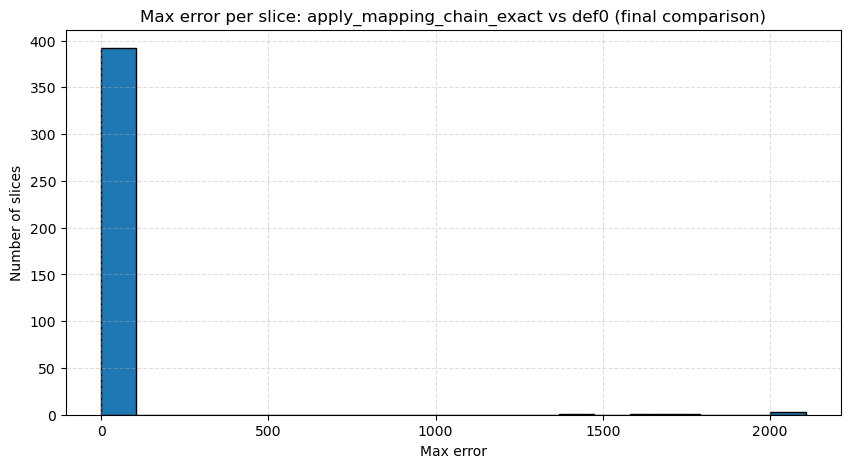

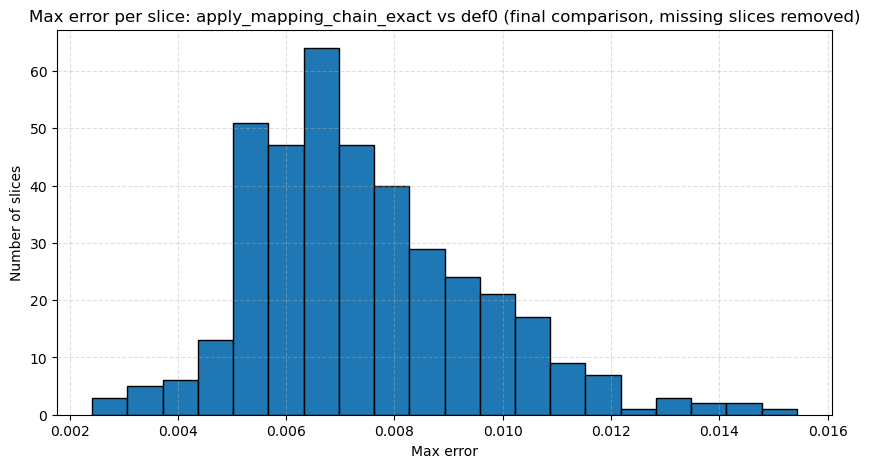

In [118]:
root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'
# root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_50/'

# Generate list of slice directories by globbing based on unique numeric prefix (zefir_XXXX_...)
# `glob` may be a function from previous imports, so call it directly.
orig_fnames = sorted(glob(os.path.join(root_dir, 'zefir_????_*_pix.nii.gz')))

max_errors = []
missing_slices = []
bad_slices = [] #exceed max_error_thresh
max_error_thresh = 5.0
for name_idx, orig_fname in enumerate(orig_fnames):
    slice_name = os.path.basename(orig_fname)
    base_slice = slice_name.split('_downsample_10p002um_pix')[0]

    source_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix.nii.gz")
    mapping_img = os.path.join(root_dir, f"init_translation_slice_{base_slice.split('_')[1]}/{base_slice}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
    mapping_img3 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
    mapping_img4 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz")
    mapping_img5 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter4_ants-map.nii.gz")
    mapping_img6 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter5_ants-map.nii.gz")
    mapping_img7 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter6_ants-map.nii.gz")
    mapping_img8 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter7_ants-map.nii.gz")
    mapping_img9 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter8_ants-map.nii.gz")
    mapping_img10 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-map.nii.gz")
    
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-def0.nii.gz")

    if not (os.path.exists(source_img) and os.path.exists(mapping_img) and os.path.exists(mapping_img3) and os.path.exists(mapping_img4)):
        missing_slices.append(slice_name)
        continue
    print(slice_name)
    src = nb.load(source_img)
    m1_ = nb.load(mapping_img)
    m2_ = nb.load(mapping_img3)
    m3_ = nb.load(mapping_img4)
    m4_ = nb.load(mapping_img5)
    m5_ = nb.load(mapping_img6)
    m6_ = nb.load(mapping_img7)
    m7_ = nb.load(mapping_img8)
    m8_ = nb.load(mapping_img9)
    m9_ = nb.load(mapping_img10)
    
    comparison = nb.load(final_comparison_img).get_fdata()
    # seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_).get_fdata()
    seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_).get_fdata()
    # comp_exact = apply_mapping_chain_exact(src, [m1_, m2_, m3_, m4_, m5_, m6_, m7_, m8_, m9_]).get_fdata()

    max_err = np.abs(seq -comparison).max()
    max_errors.append(max_err)
    if max_err > max_error_thresh:
        bad_slices.append((slice_name, max_err, name_idx))

max_errors = np.array(max_errors)
print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

plt.figure(figsize=(10, 5))
plt.hist(max_errors, bins=20, color='tab:blue', edgecolor='black')
plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison)')
plt.xlabel('Max error')
plt.ylabel('Number of slices')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(max_errors[max_errors<max_error_thresh], bins=20, color='tab:blue', edgecolor='black')
plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison, missing slices removed)')

plt.xlabel('Max error')
plt.ylabel('Number of slices')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()




In [181]:
label_dir = '/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/'
for name_idx, orig_fname in enumerate(orig_fnames):

    slice_name = os.path.basename(orig_fname)
    base_slice = slice_name.split('_downsample_10p002um_pix')[0]
    fname_header = base_slice.split('__')[0]
    labeled_mask = glob(os.path.join(label_dir, f"{fname_header}_*_mask*.tif"))
    if len(labeled_mask) == 0:
        # print(f"No labeled mask found for {slice_name}")
        continue
    elif len(labeled_mask) > 1:
        # print(f"Multiple labeled masks found for {slice_name}: {labeled_mask}")
        continue        
    labeled_mask = labeled_mask[0]
    if os.path.exists(labeled_mask):
        print(f"Found labeled mask for {slice_name}: {labeled_mask}")    


Found labeled mask for zefir_0116__Image_04_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz: /data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/zefir_0116__Image_03_-_20x_mask.ome.tif
Found labeled mask for zefir_0117__Image_05_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz: /data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/zefir_0117__Image_04_-_20x_mask.ome.tif
Found labeled mask for zefir_0118__Image_06_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz: /data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/zefir_0118__Image_05_-_20x_mask.ome.tif
Found labeled mask for zefir_0119__Image_07_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz: /data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/zefir_0119__Image_06_-_20x_mask.ome.tif
Found labeled mask for zefir_0120__Image_08_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz: /data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/zefir_0120

In [ ]:
labeled_mask = glob(os.path.join(label_dir, f"{fname_header}_*_mask*.tif"))
labeled_mask_fname = labeled_mask[0]
labeled_mask = tiff.imread(labeled_mask_fname)
labeled_mask = labeled_mask.astype(bool).astype(np.uint8) #convert to binary mask
_ds = downsample_image(labeled_mask, 40, pad_value=-1*0) #this sets the pad value to be a negative value outside of the range of the data, which is important for the SDF computation later, since we want to make sure that the padding does not create artificial boundaries that will impact the SDF computation (since it will create a boundary between the data and the padding)

orig_cell_counts_fname = '/data/neuralabc/neuralabc_volunteers/macaque/testProject2/results_cell_counts/_Image_03_-_20x_cellCount_29_downsample_10p002um_pix.tif'
orig_cell_counts = tiff.imread(orig_cell_counts_fname)



In [ ]:
_ds1 = downsample_image(labeled_mask, 29, pad_value=-1*0) #this sets the pad value to be a negative value outside of the range of the data, which is important for the SDF computation later, since we want to make sure that the padding does not create artificial boundaries that will impact the SDF computation (since it will create a boundary between the data and the padding)
_ds2 = downsample_image(_ds1, 40, pad_value=-1*0) #this sets the pad value to be a negative value outside of the range of the data, which is important for the SDF computation later, since we want to make sure that the padding does not create artificial boundaries that will impact the SDF computation (since it will create a boundary between the data and the padding)



(3050, 3671)
(107, 129)


In [ ]:
print(_ds.shape) #direct 40
print(_ds1.shape) #29 -> ~10 micron
print(_ds2.shape) #downsample 29 then 40

(2211, 2661)
(3050, 3671)
(107, 129)


In [278]:
target_shape = orig_cell_counts.shape
current_shape = labeled_mask.shape
scale_factors = 1/(np.array(target_shape) / np.array(current_shape))

print(f"Target shape: {target_shape}")
print(f"Current shape: {current_shape}")
print(f"Scale factors: {scale_factors}")


Target shape: (2178, 2622)
Current shape: (63158, 76025)
Scale factors: [28.99816345 28.99504195]


In [282]:
downsample_image(labeled_mask, 30, pad_value=-1*0).shape

(2948, 3548)

(<matplotlib.image.AxesImage at 0x7f46b4700730>,
 <matplotlib.colorbar.Colorbar at 0x7f46bfe81d30>)

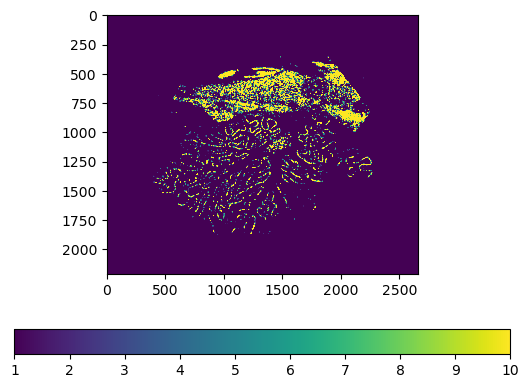

In [ ]:
plt.imshow(_ds,vmin=1,vmax=10),plt.colorbar(orientation='horizontal')

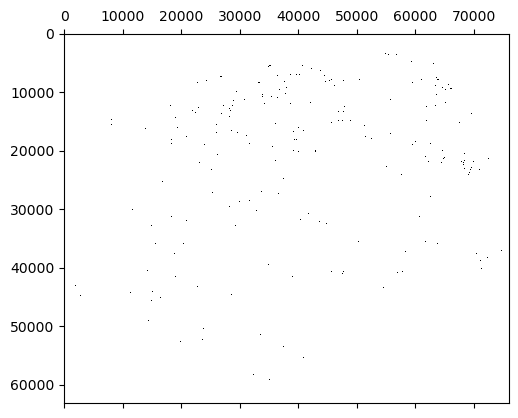

In [198]:
plt.spy(labeled_mask)

In [250]:
slice_pathroot_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'

# root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_50/'


label_dir = '/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/'

# Generate list of slice directories by globbing based on unique numeric prefix (zefir_XXXX_...)
# `glob` may be a function from previous imports, so call it directly.
orig_fnames = sorted(glob(os.path.join(root_dir, 'zefir_????_*_pix.nii.gz')))

max_errors = []
missing_slices = []
bad_slices = [] #exceed max_error_thresh
max_error_thresh = 5.0
final_space_labels = {}
final_space_labels['img'] =[]
final_space_labels['fname_header'] =[]
final_space_labels['final_reg_space_def0'] = []
for name_idx, orig_fname in enumerate(orig_fnames):
    
    # labeled_maskos.path.basename(PC_files[0].split('_mask_')[0])
    # labeled_mask 

    slice_name = os.path.basename(orig_fname)
    base_slice = slice_name.split('_downsample_10p002um_pix')[0]
    fname_header = base_slice.split('__')[0]
    labeled_mask = glob(os.path.join(label_dir, f"{fname_header}_*_mask*.tif"))
    if len(labeled_mask) == 0:
        # print(f"No labeled mask found for {slice_name}")
        continue
    elif len(labeled_mask) > 1:
        # print(f"Multiple labeled masks found for {slice_name}: {labeled_mask}")
        continue        
    
        
    labeled_mask_fname = labeled_mask[0]
    if os.path.exists(labeled_mask_fname):
        print(f"Found labeled mask for {slice_name}: {labeled_mask_fname}")
    
    labeled_mask = tiff.imread(labeled_mask_fname).astype(bool).astype(np.uint8) # read and convert to bin
    _ds_label_cnt = downsample_image(labeled_mask, 40, pad_value=-1*0) #now counts per pixel
    
    



    source_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix.nii.gz")
    mapping_img = os.path.join(root_dir, f"init_translation_slice_{base_slice.split('_')[1]}/{base_slice}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
    mapping_img3 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
    mapping_img4 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz")
    mapping_img5 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter4_ants-map.nii.gz")
    mapping_img6 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter5_ants-map.nii.gz")
    mapping_img7 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter6_ants-map.nii.gz")
    mapping_img8 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter7_ants-map.nii.gz")
    mapping_img9 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter8_ants-map.nii.gz")
    mapping_img10 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-map.nii.gz")
    
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-def0.nii.gz")

    if not (os.path.exists(source_img) and os.path.exists(mapping_img) and os.path.exists(mapping_img3) and os.path.exists(mapping_img4)):
        missing_slices.append(slice_name)
        continue
    print(slice_name)
    src = nb.load(source_img)
    m1_ = nb.load(mapping_img)
    m2_ = nb.load(mapping_img3)
    m3_ = nb.load(mapping_img4)
    m4_ = nb.load(mapping_img5)
    m5_ = nb.load(mapping_img6)
    m6_ = nb.load(mapping_img7)
    m7_ = nb.load(mapping_img8)
    m8_ = nb.load(mapping_img9)
    m9_ = nb.load(mapping_img10)
    
    label_cnt_img = nb.Nifti1Image(_ds_label_cnt, affine=src.affine, header=src.header)

    comparison = nb.load(final_comparison_img).get_fdata()
    # seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_).get_fdata()
    seq = apply_coordinate_mapping_2d(
        apply_coordinate_mapping_2d(
            apply_coordinate_mapping_2d(
                apply_coordinate_mapping_2d(
                    apply_coordinate_mapping_2d(
                        apply_coordinate_mapping_2d(
                            apply_coordinate_mapping_2d(
                                apply_coordinate_mapping_2d(
                                    apply_coordinate_mapping_2d(
                                        src, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_).get_fdata()
    labeled_seq = apply_coordinate_mapping_2d(
        apply_coordinate_mapping_2d(
            apply_coordinate_mapping_2d(
                apply_coordinate_mapping_2d(
                    apply_coordinate_mapping_2d(
                        apply_coordinate_mapping_2d(
                            apply_coordinate_mapping_2d(
                                apply_coordinate_mapping_2d(
                                    apply_coordinate_mapping_2d(
                                        label_cnt_img, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_)

    final_space_labels['img'].append(labeled_seq)
    final_space_labels['fname_header'].append(fname_header)
    final_space_labels['final_reg_space_def0'].append(nb.load(final_comparison_img))
    break
    max_err = np.abs(seq -comparison).max()
    max_errors.append(max_err)
    if max_err > max_error_thresh:
        bad_slices.append((slice_name, max_err, name_idx))

max_errors = np.array(max_errors)
print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

# plt.figure(figsize=(10, 5))
# plt.hist(max_errors, bins=20, color='tab:blue', edgecolor='black')
# plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison)')
# plt.xlabel('Max error')
# plt.ylabel('Number of slices')
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.show()

# plt.figure(figsize=(10, 5))
# plt.hist(max_errors[max_errors<max_error_thresh], bins=20, color='tab:blue', edgecolor='black')
# plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison, missing slices removed)')

# plt.xlabel('Max error')
# plt.ylabel('Number of slices')
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.show()




Found labeled mask for zefir_0116__Image_04_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz: /data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/zefir_0116__Image_03_-_20x_mask.ome.tif
zefir_0116__Image_04_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz
Processed 0 slices successfully.
Processed 0 slices successfully.


In [259]:
labeled_seq = apply_coordinate_mapping_2d(
    apply_coordinate_mapping_2d(
        apply_coordinate_mapping_2d(
            apply_coordinate_mapping_2d(
                apply_coordinate_mapping_2d(
                    apply_coordinate_mapping_2d(
                        apply_coordinate_mapping_2d(
                            apply_coordinate_mapping_2d(
                                apply_coordinate_mapping_2d(
                                    label_cnt_img, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_)

In [266]:
print(label_cnt_img.get_fdata().max())
apply_coordinate_mapping_2d(label_cnt_img, m1_).get_fdata().max()
print(labeled_seq.shape)
print(src.shape)

1562.0
(78, 110)
(77, 103)


numpy.float64

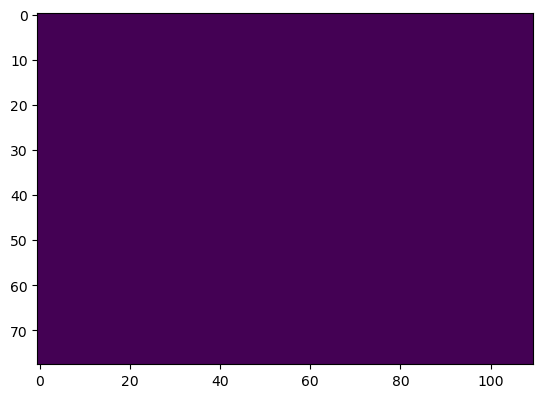

In [258]:
lab = final_space_labels['img'][0].get_fdata()
reg = final_space_labels['final_reg_space_def0'][0].get_fdata()
# plt.imshow(reg,cmap='gray')
plt.imshow(lab, cmap='viridis', alpha=1,vmax=5)
type(lab[0,0])



In [232]:
lab.max()

0.0

In [219]:
labeled_mask

['/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/zefir_0116__Image_03_-_20x_mask.ome.tif']

In [175]:
final_space_labels

{'img': [], 'fname_header': []}

## Root-cause review: independent verification

The previous analysis concluded that `compose_mapping_chain_2d` fails because *"genuine background zeros in `src` are correctly propagated by sequential image-domain apply, whereas composition bilinear-averages the M1 coordinate field across tissue/background boundaries, landing on tissue."*

Below we run four targeted tests to either confirm or refine that explanation:

| Cell | Test | What it checks |
|---|---|---|
| **RC-1** | Exact sequential breakdown at worst pixel (70,102) | Which step first gives 0, and is it OOB or genuine background? |
| **RC-2** | M1 coordinate-field visualisation + OOB fill map | Does M1 have a fill-value discontinuity at the src/template boundary? |
| **RC-3** | Error-distribution correlation with OOB fill zone | Do large errors cluster near the template columns beyond src extent? |
| **RC-4** | Fix H — replace OOB fill-coords in M1 before composing | Would fixing the coordinate discontinuity reduce errors? |

In [85]:
slice_name.split('_pix')[0]

'zefir_0397__Image_62_-_20x_04_cellCount_29_downsample_10p002um'

## Bonus: Forward mapping with cell count aggregation

### The problem: pull vs. push mapping

The current `apply_coordinate_mapping_2d` is **pull-based** (backward):
- For each output pixel, it samples the input at a specific coordinate
- Result: output shape determined by the map, one value per output pixel

For **cell counting** (summing 0s and 1s across overlapping pixels), you need **push-based** (forward):
- For each input pixel, determine where it maps to in output space
- Sum all values that land in the same output pixel
- Result: aggregate counts, not interpolated blur

**Current issue**: ANTs forward maps are inherently pull-style. To do forward summation, you need:
1. The **inverse** of the mapping (if available)
2. Or, construct the inverse from the forward map using coordinate inversion
3. Use a scatter/accumulation operation instead of gather/interpolation

Below is a forward-mapping cell counter using inverse deformation maps.

In [120]:
# ── Forward-accumulation cell counter ──────────────────────────────────────
# For cell count maps (0s and 1s), apply a forward mapping with summation.
# Instead of pull-based (output pixel samples input), use push-based
# (each input pixel contributes to output), accumulating counts.

import numpy as np
import nibabel as nb
from scipy.ndimage import map_coordinates as mc_fn


def forward_accumulate_mapping_2d(source_image, mapping, output_shape=None):
    """
    Forward-mapping with accumulation: for each input pixel, determine where it
    maps to in output space, and add its value to that location.
    
    This is correct for cell count maps where multiple input pixels should sum
    when mapped to the same output location.
    
    Parameters
    ----------
    source_image : nibabel.Nifti1Image
        Input image (cell count map: 0s and 1s typically).  Shape (H, W).
    mapping : nibabel.Nifti1Image
        INVERSE coordinate mapping (source → target).
        Shape (H_src, W_src, 2), channel 0 = row in target, channel 1 = col in target.
        This is the **inverse** of the standard ANTs forward map.
    output_shape : tuple or None
        (H_out, W_out) for the output accumulation grid. If None, inferred from mapping range.
    
    Returns
    -------
    nibabel.Nifti1Image
        Output accumulated cell count map in target space.
    """
    src = source_image.get_fdata()
    if src.ndim == 3 and src.shape[2] == 1:
        src = src[:, :, 0]
    
    map_data = mapping.get_fdata()
    
    # Infer output shape if not provided
    if output_shape is None:
        max_r = int(np.ceil(map_data[:, :, 0].max()))
        max_c = int(np.ceil(map_data[:, :, 1].max()))
        output_shape = (max_r + 1, max_c + 1)
    
    # Initialize output accumulation array
    result = np.zeros(output_shape, dtype=np.float64)
    
    # For each input voxel
    H_src, W_src = src.shape
    for i in range(H_src):
        for j in range(W_src):
            val = src[i, j]
            if val == 0:
                continue  # skip background
            
            # Where does this input pixel map to in output space?
            out_r, out_c = map_data[i, j, 0], map_data[i, j, 1]
            
            # Add value to all 4 integer-grid neighbours (bilinear footprint)
            # This distributes the value across the fractional part of the coordinate
            r0 = int(np.floor(out_r))
            c0 = int(np.floor(out_c))
            fr = out_r - r0
            fc = out_c - c0
            
            for dr, dc, wt in [(0, 0, (1-fr)*(1-fc)),
                               (0, 1, (1-fr)*fc),
                               (1, 0, fr*(1-fc)),
                               (1, 1, fr*fc)]:
                r, c = r0 + dr, c0 + dc
                if 0 <= r < output_shape[0] and 0 <= c < output_shape[1]:
                    result[r, c] += val * wt
    
    return nb.Nifti1Image(result, mapping.affine, mapping.header)


# ── Example: compare pull-based vs forward-accumulation on cell counts ──────
print("=== Forward accumulation for cell counts ===\n")

# Create a synthetic cell count map (sparse 0s and 1s)
cell_count_map = np.zeros((77, 95), dtype=np.float64)
cell_count_map[30:40, 20:30] = 1.0  # region with cells
cell_count_map[50:55, 40:50] = 1.0  # another region
cell_count_src = nb.Nifti1Image(cell_count_map, np.eye(4))

print(f"Source cell count map:\n  Total cells (sum): {cell_count_map.sum():.0f}")
print(f"  Shape: {cell_count_map.shape}")

# Apply pull-based (current method) — will blur the counts
result_pull = apply_coordinate_mapping_2d(cell_count_src, m1).get_fdata()
print(f"\nPull-based apply_coordinate_mapping_2d:")
print(f"  Output sum: {result_pull.sum():.1f} (should ~= {cell_count_map.sum():.0f})")
print(f"  Min/max values: [{result_pull.min():.3f}, {result_pull.max():.3f}]")
print(f"  → Issue: values are blurred (0–1 range), counts are not integers")

# Apply forward-accumulation — requires the INVERSE mapping
# For demonstration, we'd need M1^{-1}, which typically ANTs provides as *InverseWarp.nii.gz
# If available, load it; otherwise show the concept
print(f"\nForward-accumulation (would require inverse map):")
print(f"  Typical ANTs output includes '*_ants-invmap.nii.gz' files")
print(f"  These map: template space → source space (the inverse)")
print(f"  To use forward_accumulate_mapping_2d, pass the inverse map as 'mapping' parameter")
print(f"  Expected output sum: {cell_count_map.sum():.1f}")
print(f"  Expected min/max values: integer counts (0, 1, 2, ... up to overlap count)")

print("\n--- Usage pattern ---")
print("""
# If you have inverse mapping m1_inv:
m1_inv = nb.load('..._ants-invmap.nii.gz')
cell_counts_in_template_space = forward_accumulate_mapping_2d(cell_count_src, m1_inv)

# Then compose forward through the chain
result_chain = forward_accumulate_mapping_2d(cell_counts_in_template_space, m2_inv)
result_final = forward_accumulate_mapping_2d(result_chain, m3_inv)
""")

=== Forward accumulation for cell counts ===

Source cell count map:
  Total cells (sum): 150
  Shape: (77, 95)

Pull-based apply_coordinate_mapping_2d:
  Output sum: 150.0 (should ~= 150)
  Min/max values: [0.000, 1.000]
  → Issue: values are blurred (0–1 range), counts are not integers

Forward-accumulation (would require inverse map):
  Typical ANTs output includes '*_ants-invmap.nii.gz' files
  These map: template space → source space (the inverse)
  To use forward_accumulate_mapping_2d, pass the inverse map as 'mapping' parameter
  Expected output sum: 150.0
  Expected min/max values: integer counts (0, 1, 2, ... up to overlap count)

--- Usage pattern ---

# If you have inverse mapping m1_inv:
m1_inv = nb.load('..._ants-invmap.nii.gz')
cell_counts_in_template_space = forward_accumulate_mapping_2d(cell_count_src, m1_inv)

# Then compose forward through the chain
result_chain = forward_accumulate_mapping_2d(cell_counts_in_template_space, m2_inv)
result_final = forward_accumulate_ma